In [1]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

folder_path = 'mouseDataMainStudy'

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

dataframes = [pd.read_csv(file) for file in csv_files]


In [2]:
exclusion_df = pd.read_csv('trial_exclusion_overview.csv') 
excluded = exclusion_df[exclusion_df['trial_excl'] == 1][['id', 'round', 'trial']]

dataframes_without_excluded = []

for df in dataframes:
    if all(col in df.columns for col in ['id', 'round', 'trial']):
        merged = df.merge(excluded, on=['id', 'round', 'trial'], how='left', indicator=True)
        df_cleaned = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
        dataframes_without_excluded.append(df_cleaned)
    else:
        dataframes_without_excluded.append(df) 

In [3]:
block_pairs = [(1, 2), (3, 4), (5, 6), (7, 8)]
all_blocks = {f"{a}_{b}": [] for a, b in block_pairs}

for df in dataframes_without_excluded:
    df = df[df['phase'] != 'waitingForTarget']  # Phase-Filter
    for a, b in block_pairs:
        df_block = df[df['round'].isin([a, b])].reset_index(drop=True)
        all_blocks[f"{a}_{b}"].append(df_block)

In [4]:
all_blocks["1_2"][0].iloc[0:50]

,id,round,trial,version,timestamp,frame,pointerX,pointerY,phase,event,side,delay
0,1062,1,2,rld,14:08:57.978,171038,0.034,0.069,activeTracking,targetAppeared,left,False
1,1062,1,2,rld,14:08:57.982,171039,0.034,0.069,activeTracking,noEvent,left,False
2,1062,1,2,rld,14:08:57.986,171040,0.034,0.069,activeTracking,noEvent,left,False
3,1062,1,2,rld,14:08:57.990,171041,0.034,0.069,activeTracking,noEvent,left,False
4,1062,1,2,rld,14:08:57.995,171042,0.034,0.069,activeTracking,noEvent,left,False
5,1062,1,2,rld,14:08:57.999,171043,0.034,0.069,activeTracking,noEvent,left,False
6,1062,1,2,rld,14:08:58.003,171044,0.034,0.069,activeTracking,noEvent,left,False
7,1062,1,2,rld,14:08:58.007,171045,0.034,0.069,activeTracking,noEvent,left,False
8,1062,1,2,rld,14:08:58.011,171046,0.034,0.069,activeTracking,noEvent,left,False
9,1062,1,2,rld,14:08:58.016,171047,0.034,0.069,activeTracking,noEvent,left,False


In [5]:
def get_target_loc(mouse_x):
    if len(mouse_x) < 2:
        return None
    if mouse_x[-1] > mouse_x[0]:
        return "right"
    elif mouse_x[-1] < mouse_x[0]:
        return "left"
    else:
        return "none"


In [6]:
def get_delay(version, target_loc):
    if target_loc is None or target_loc == "none":
        return None

    if version == "rld" and target_loc == "right":
        return 1
    if version == "rld" and target_loc == "left":
        return 0
    if version == "lld" and target_loc == "left":
        return 1
    if version == "lld" and target_loc == "right":
        return 0

    return None


In [7]:
def compute_rel_time(timestamp_list):
    if not timestamp_list:
        return []

    t = pd.to_datetime(
        timestamp_list,
        format="%H:%M:%S.%f"
    )

    rel_time = (t - t[0]).total_seconds()
    return rel_time.tolist()


In [8]:
def compute_dist_to_target_from_endpoint(mouse_x, mouse_y):
    x = np.array(mouse_x)
    y = np.array(mouse_y)

    x_end = x[-1]
    y_end = y[-1]

    dist = np.sqrt((x - x_end)**2 + (y - y_end)**2)
    return dist.tolist()

In [9]:
def compute_dist_prop(dist_list):
    """
    Computes proportional Euclidean distance as in Hehman et al., 2015
    dist_list: Liste der Abstände zum Ziel (dist_to_target)
    """
    dist_arr = np.array(dist_list)
    dist_max = np.max(dist_arr)
    
    if dist_max > 0:
        dist_prop = 1 - dist_arr / dist_max
    else:
        dist_prop = np.full_like(dist_arr, np.nan, dtype=float)
    
    return dist_prop.tolist()


In [10]:
def compute_rt_05pct_target(mouse_x_list, mouse_y_list, rel_time_list, threshold_pct=0.05):
    """
    Berechnet die Reaktionszeit (Bewegungsinitiierung) für einen Trial.

    Parameters
    ----------
    mouse_x_list : list oder np.array
        X-Koordinaten der Mausbewegung
    mouse_y_list : list oder np.array
        Y-Koordinaten der Mausbewegung
    rel_time_list : list oder np.array
        Relative Zeit ab Target appearance (bereits vorhanden)
    threshold_pct : float
        Prozentualer Anteil der Gesamtstrecke, ab dem Bewegung zählt (default=0.05)

    Returns
    -------
    rt : float
        Reaktionszeit in Sekunden (erste Bewegung > threshold), np.nan falls nie erreicht
    """
    mouse_x = np.array(mouse_x_list)
    mouse_y = np.array(mouse_y_list)
    rel_time = np.array(rel_time_list)

    start_x, start_y = mouse_x[0], mouse_y[0]
    end_x, end_y = mouse_x[-1], mouse_y[-1]

    total_distance = np.sqrt((end_x - start_x)**2 + (end_y - start_y)**2)
    threshold_distance = threshold_pct * total_distance

    dist_to_target = np.sqrt((end_x - mouse_x)**2 + (end_y - mouse_y)**2)
    progr_toward_target = dist_to_target[0] - dist_to_target 

    indices = np.where(progr_toward_target >= threshold_distance)[0]

    if len(indices) == 0:
        return np.nan 

    return rel_time[indices[0]]


In [11]:
def compute_velocity_towards_target(mouse_x, mouse_y, rel_time, x_end, y_end):
    mouse_x = np.array(mouse_x)
    mouse_y = np.array(mouse_y)
    rel_time = np.array(rel_time)

    dx = np.diff(mouse_x)
    dy = np.diff(mouse_y)
    dt = np.diff(rel_time)

    speed_x = np.divide(dx, dt, out=np.full_like(dx, np.nan), where=dt > 0)
    speed_y = np.divide(dy, dt, out=np.full_like(dy, np.nan), where=dt > 0)

    vx = x_end - mouse_x[:-1]
    vy = y_end - mouse_y[:-1]
    v_len = np.sqrt(vx**2 + vy**2)

    vx_unit = np.divide(vx, v_len, out=np.full_like(vx, np.nan), where=v_len > 0)
    vy_unit = np.divide(vy, v_len, out=np.full_like(vy, np.nan), where=v_len > 0)

    velocity_towards_target = speed_x * vx_unit + speed_y * vy_unit

    return velocity_towards_target


In [12]:
grouped_blocks = {
    '1_2': [],
    '3_4': [],
    '5_6': [],
    '7_8': []
}

for key in grouped_blocks.keys():
    for df in all_blocks[key]:
        df_grouped = df.groupby(['round', 'trial']).agg({
            'timestamp': list,
            'pointerX': list,
            'pointerY': list,
            'version': 'first',
            'id': 'first'
        }).reset_index()
        df_grouped['target_loc'] = df_grouped['pointerX'].apply(get_target_loc)

        df_grouped['delay'] = df_grouped.apply(
            lambda row: get_delay(row['version'], row['target_loc']),
            axis=1
        )
        df_grouped['rel_time'] = df_grouped['timestamp'].apply(compute_rel_time)

        df_grouped['dist_to_target'] = df_grouped.apply(
            lambda row: compute_dist_to_target_from_endpoint(
                row['pointerX'],
                row['pointerY']
            ),
            axis=1
        )

        df_grouped['dist_prop'] = df_grouped['dist_to_target'].apply(compute_dist_prop)

        df_grouped['rt_05pct_target'] = df_grouped.apply(
            lambda row: compute_rt_05pct_target(
                row['pointerX'], row['pointerY'], row['rel_time']
            ),
            axis=1
        )

        df_grouped['rt'] = df_grouped['rel_time'].apply(lambda x: x[-1] if len(x) > 0 else None)

        df_grouped['velocity_towards_target'] = df_grouped.apply(
            lambda row: compute_velocity_towards_target(
                row['pointerX'],
                row['pointerY'],
                row['rel_time'],
                row['pointerX'][-1],
                row['pointerY'][-1]
            ),
            axis=1
        )

        df_grouped['velocity_mean'] = df_grouped['velocity_towards_target'].apply(
            lambda x: np.mean(x) if len(x) > 0 and not np.all(np.isnan(x)) else np.nan
        )
        
        df_grouped['velocity_max'] = df_grouped['velocity_towards_target'].apply(
            lambda x: np.nanmax(x) if len(x) > 0 and not np.all(np.isnan(x)) else np.nan
        )
        
        df_grouped['velocity_std'] = df_grouped['velocity_towards_target'].apply(
            lambda x: np.nanstd(x) if len(x) > 0 else np.nan
        )


        grouped_blocks[key].append(df_grouped)


In [13]:
grouped_blocks["1_2"][0].head()

,round,trial,timestamp,pointerX,pointerY,version,id,target_loc,delay,rel_time,dist_to_target,dist_prop,rt_05pct_target,rt,velocity_towards_target,velocity_mean,velocity_max,velocity_std
0,1,2,"[14:08:57.978, 14:08:57.982, 14:08:57.986, 14:...","[0.034, 0.034, 0.034, 0.034, 0.034, 0.034, 0.0...","[0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.0...",rld,1062,left,0,"[0.0, 0.004, 0.008, 0.012, 0.017, 0.021, 0.025...","[2.5640393912730746, 2.5640393912730746, 2.564...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.233,0.467,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",5.582831,23.495507,8.108013
1,1,3,"[14:08:59.816, 14:08:59.820, 14:08:59.824, 14:...","[-0.008, -0.008, -0.008, -0.008, -0.008, -0.00...","[0.018, 0.018, 0.018, 0.018, 0.018, 0.018, 0.0...",rld,1062,left,0,"[0.0, 0.004, 0.008, 0.012, 0.017, 0.021, 0.025...","[2.4750032323211215, 2.4750032323211215, 2.475...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.238,0.533,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,39.649077,10.253400
2,1,4,"[14:09:01.750, 14:09:01.753, 14:09:01.757, 14:...","[0.219, 0.219, 0.219, 0.219, 0.219, 0.219, 0.2...","[0.077, 0.077, 0.077, 0.077, 0.077, 0.077, 0.0...",rld,1062,left,0,"[0.0, 0.003, 0.007, 0.012, 0.016, 0.02, 0.025,...","[2.739197875291232, 2.739197875291232, 2.73919...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.233,0.483,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",NaN,45.983834,11.571774
3,1,5,"[14:09:03.516, 14:09:03.520, 14:09:03.524, 14:...","[-0.177, -0.177, -0.177, -0.177, -0.177, -0.17...","[-0.032, -0.032, -0.032, -0.032, -0.032, -0.03...",rld,1062,right,1,"[0.0, 0.004, 0.008, 0.012, 0.017, 0.021, 0.025...","[2.6277855696384362, 2.6277855696384362, 2.627...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.246,0.504,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,31.396976,9.164958
4,1,8,"[14:09:12.793, 14:09:12.796, 14:09:12.801, 14:...","[-0.034, -0.034, -0.034, -0.034, -0.034, -0.03...","[0.119, 0.119, 0.119, 0.119, 0.119, 0.119, 0.1...",rld,1062,left,0,"[0.0, 0.003, 0.008, 0.012, 0.017, 0.021, 0.025...","[2.686132721962934, 2.686132721962934, 2.68613...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.221,0.637,"[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",4.302561,35.127672,7.757890


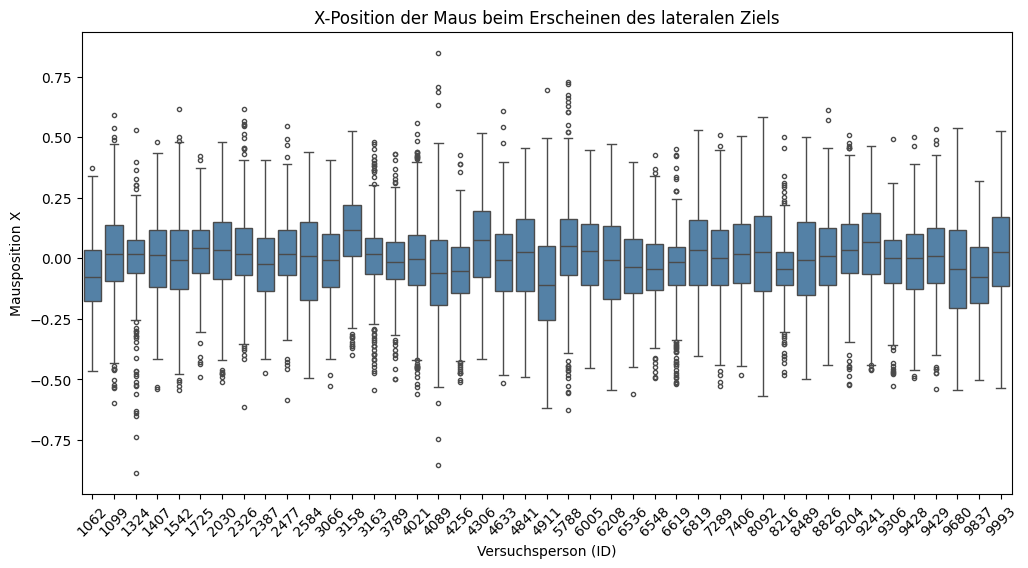

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rows = []
for key in grouped_blocks.keys():
    for df in grouped_blocks[key]:
        for _, row in df.iterrows():
            if len(row['pointerX']) > 0:
                rows.append({
                    'id': row['id'],
                    'first_pointerX': row['pointerX'][0]
                })

df_first_x = pd.DataFrame(rows)

plt.figure(figsize=(12,6))
sns.boxplot(x='id', y='first_pointerX', data=df_first_x, color='steelblue', fliersize=3)
plt.title("X-Position der Maus beim Erscheinen des lateralen Ziels")
plt.xlabel("Versuchsperson (ID)")
plt.ylabel("Mausposition X")
plt.xticks(rotation=45)
plt.show()


C:\Users\m_uel\AppData\Local\Temp\ipykernel_17148\3072822986.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  timestamps = pd.to_datetime(trial_row['timestamp'])


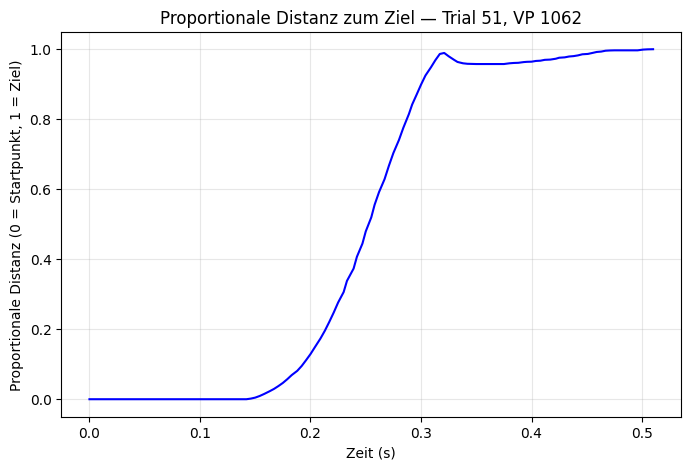

In [15]:
df = grouped_blocks["1_2"][0]
trial_row = df[(df['id'] == 1062) & (df['round'] == 1) & (df['trial'] == 51)].iloc[0]

timestamps = pd.to_datetime(trial_row['timestamp'])
rel_time = (timestamps - timestamps[0]).total_seconds()
dist_prop = trial_row['dist_prop']

plt.figure(figsize=(8,5))
plt.plot(rel_time, dist_prop, color='blue')
plt.title("Proportionale Distanz zum Ziel — Trial 51, VP 1062")
plt.xlabel("Zeit (s)")
plt.ylabel("Proportionale Distanz (0 = Startpunkt, 1 = Ziel)")
plt.grid(alpha=0.3)
plt.show()

In [16]:
def plot_first_n_trials_with_rt(df, participant_id, round_num, n_first=5):
    """
    Plottet proportionale Distanz zum Ziel für die ersten `n_first` Trials einer Runde
    und markiert die Bewegungsinitiierung (rt_05pct_target) als senkrechte Linie.
    
    df: DataFrame eines Blocks
    participant_id: ID der Versuchsperson
    round_num: Runde die geplottet werden soll
    n_first: Anzahl der ersten Trials, die geplottet werden sollen
    """
    
    trials = df[(df['id'] == participant_id) & (df['round'] == round_num)]
    

    trials = trials.sort_values('trial').head(n_first)
    
    for _, trial_row in trials.iterrows():
        dist_prop = trial_row['dist_prop']

        rt_sec = trial_row.get('rt_05pct_target', None)
        
        plt.figure(figsize=(8,5))
        plt.plot(trial_row["rel_time"], dist_prop, color='blue')
        if rt_sec is not None:
            plt.axvline(x=rt_sec, color='red', linestyle='--', label='Bewegungsinitiierung')
        plt.title(f"Proportionale Distanz zum Ziel — Trial {trial_row['trial']}, VP {participant_id}")
        plt.xlabel("Zeit (s)")
        plt.ylabel("Proportionale Distanz (0 = Startpunkt, 1 = Ziel)")
        plt.ylim(0, 1.05)
        if rt_sec is not None:
            plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


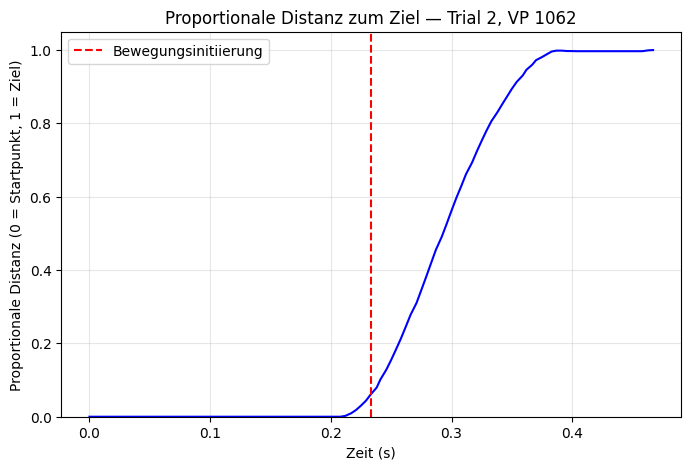

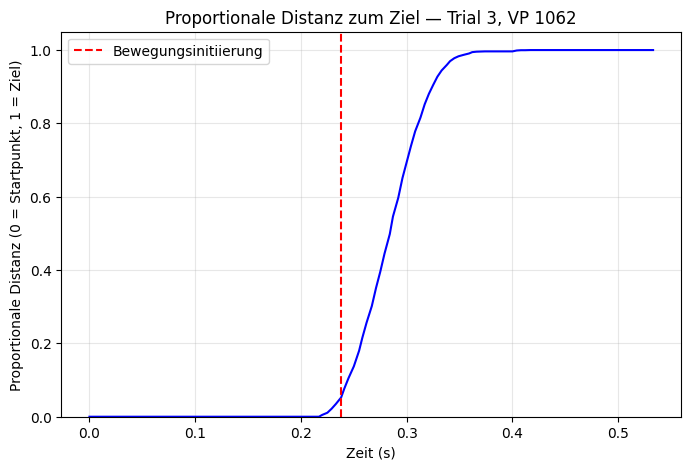

In [17]:
df = grouped_blocks["1_2"][0]
plot_first_n_trials_with_rt(df, participant_id=1062, round_num=1, n_first=2)


In [18]:
all_trials = []

for block_key, dfs in grouped_blocks.items():
    for df in dfs:
        for _, row in df.iterrows():
            all_trials.append({
                'id': row['id'],
                'version': row['version'],
                'block_f': block_key,
                'delay': row['delay'],
                'rt': row["rt_05pct_target"],
                'dist_to_target_start': row['dist_to_target'][0],
                'speed_to_target': row['velocity_towards_target'],
                'velocity_mean': row['velocity_mean'], 
                'velocity_max': row['velocity_max']
            })

# Alle Trials in ein DataFrame
df_rt = pd.DataFrame(all_trials)

df_rt_means = df_rt.groupby(['id', 'version', 'block_f', 'delay']).agg(
    rt_mean=('rt', 'mean'),
    dist_to_target_start=('dist_to_target_start', 'first'),
    velocity_mean=('velocity_mean', 'mean'),
    velocity_max=("velocity_max", "mean"),
).reset_index()

print(df_rt_means)


       id version block_f  delay   rt_mean  dist_to_target_start  \
0    1062     rld     1_2      0  0.236852              2.564039   
1    1062     rld     1_2      1  0.241885              2.627786   
2    1062     rld     3_4      0  0.231578              2.537557   
3    1062     rld     3_4      1  0.224346              2.962078   
4    1062     rld     5_6      0  0.221839              2.371864   
..    ...     ...     ...    ...       ...                   ...   
339  9993     lld     3_4      1  0.196068              2.921000   
340  9993     lld     5_6      0  0.173286              2.611992   
341  9993     lld     5_6      1  0.185377              2.629119   
342  9993     lld     7_8      0  0.177111              2.654802   
343  9993     lld     7_8      1  0.203053              2.788871   

     velocity_mean  velocity_max  
0         5.163039     30.719765  
1         5.388661     33.460768  
2         5.372548     31.764756  
3         5.576468     31.419970  
4       

In [19]:
# Mittelwerte über alle Teilnehmer pro Block und Delay
summary = df_rt_means.groupby(['block_f', 'delay']).agg(
    rt_mean_avg=('rt_mean', 'mean'),
    rt_mean_sd=('rt_mean', 'std'),
    velo_mean_avg=('velocity_mean', 'mean'),
    velo_mean_sd=('velocity_mean', 'std'),
    velo_max_avg=('velocity_max', 'mean'),
    velo_max_sd=('velocity_max', 'std'),
    n=('rt_mean', 'count')
).reset_index()

print(summary)

  block_f  delay  rt_mean_avg  rt_mean_sd  velo_mean_avg  velo_mean_sd  \
0     1_2      0     0.202656    0.023199       4.696676      1.090257   
1     1_2      1     0.202779    0.026805       4.586928      0.945148   
2     3_4      0     0.194129    0.029621       5.170757      1.256503   
3     3_4      1     0.203358    0.028163       5.023951      1.186876   
4     5_6      0     0.187295    0.024610       5.408026      1.470244   
5     5_6      1     0.201614    0.025364       5.312380      1.376742   
6     7_8      0     0.182449    0.022734       5.772124      1.397380   
7     7_8      1     0.198099    0.028526       5.335609      1.349790   

   velo_max_avg  velo_max_sd   n  
0     31.826558     9.485869  43  
1     32.009308     7.976511  43  
2     31.642492     8.855525  43  
3     32.293124     8.012329  43  
4     32.560736     8.934955  43  
5     33.045054     8.261219  43  
6     31.707426     8.333042  43  
7     32.737796     8.005754  43  


In [20]:
pivot = df_rt_means.pivot_table(
    values='rt_mean',
    index='block_f',
    columns='delay',
    aggfunc='mean'
)
print(pivot)

delay           0         1
block_f                    
1_2      0.202656  0.202779
3_4      0.194129  0.203358
5_6      0.187295  0.201614
7_8      0.182449  0.198099


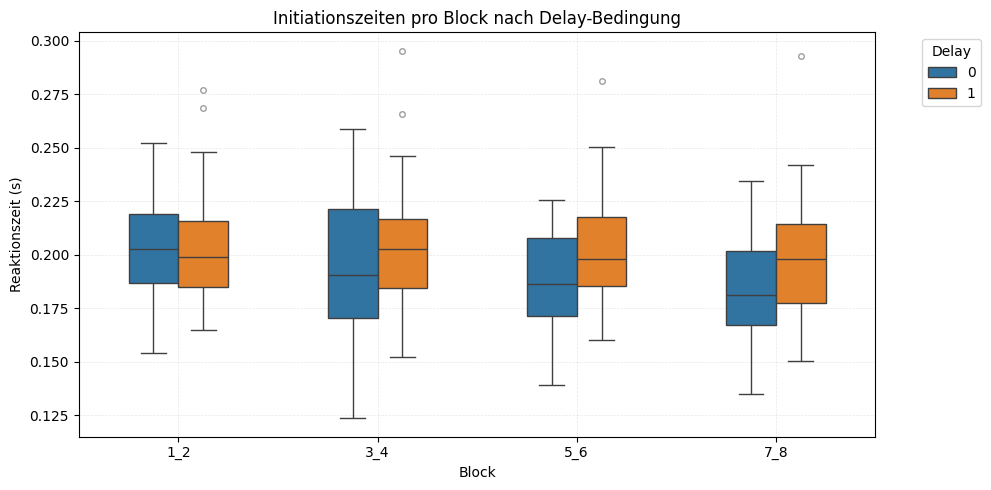

In [21]:
block_order = ['1_2','3_4','5_6','7_8']
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_rt_means,
    x='block_f',
    y='rt_mean',
    hue='delay',
    order=block_order,
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

plt.title("Initiationszeiten pro Block nach Delay-Bedingung")
plt.xlabel("Block")
plt.ylabel("Reaktionszeit (s)")
plt.legend(title='Delay')
plt.legend(title='Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()


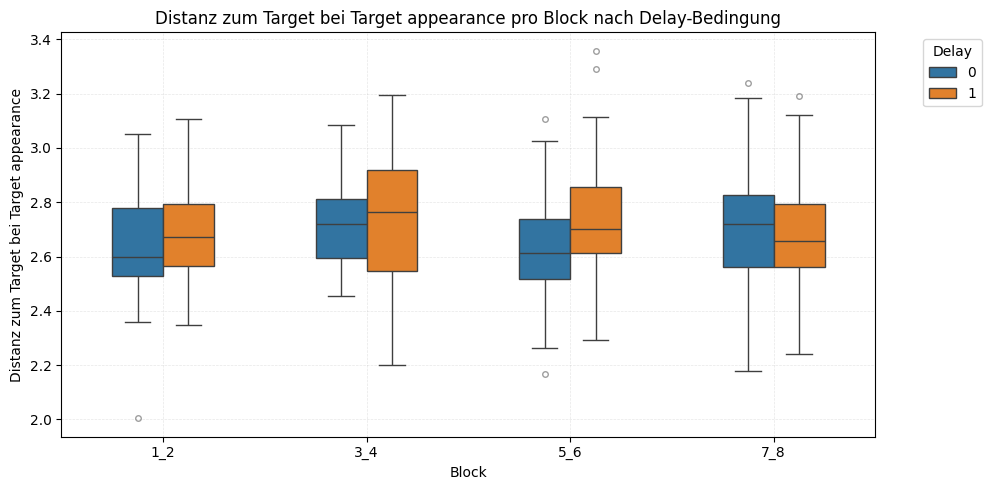

In [22]:
plt.figure(figsize=(10, 5))

box = sns.boxplot(
    data=df_rt_means, 
    x='block_f',               
    y='dist_to_target_start',
    hue='delay',                       
    order=block_order,
    width=0.5,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

plt.title("Distanz zum Target bei Target appearance pro Block nach Delay-Bedingung")
plt.xlabel("Block")
plt.ylabel("Distanz zum Target bei Target appearance")
plt.legend(title='Delay', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.show()


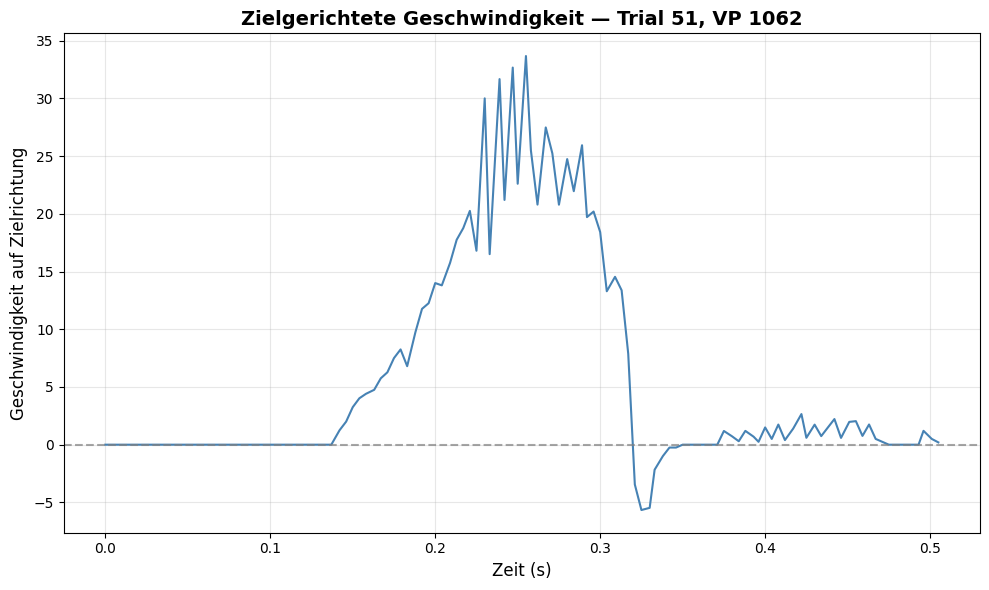

In [23]:
df = grouped_blocks["1_2"][0]
trial_row = df[(df['id'] == 1062) & (df['round'] == 1) & (df['trial'] == 51)].iloc[0]

rel_time = trial_row['rel_time']
velocity = trial_row['velocity_towards_target']

plt.figure(figsize=(10, 6))
plt.plot(rel_time[:-1], velocity, color='steelblue', linewidth=1.5)
plt.axhline(y=0, linestyle='--', color='grey', alpha=0.7)
plt.title("Zielgerichtete Geschwindigkeit — Trial 51, VP 1062", fontsize=14, fontweight='bold')
plt.xlabel("Zeit (s)", fontsize=12)
plt.ylabel("Geschwindigkeit auf Zielrichtung", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

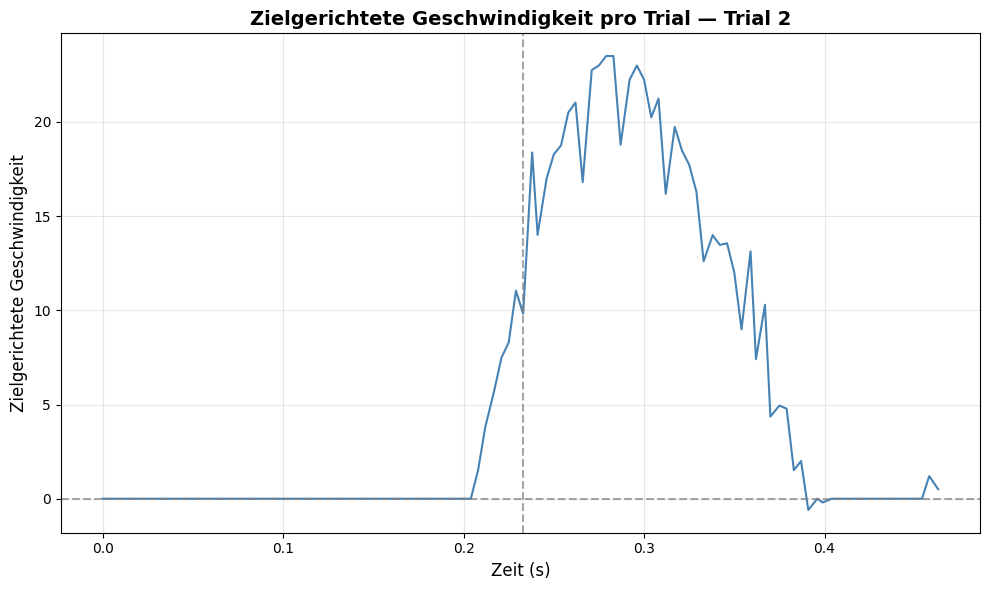

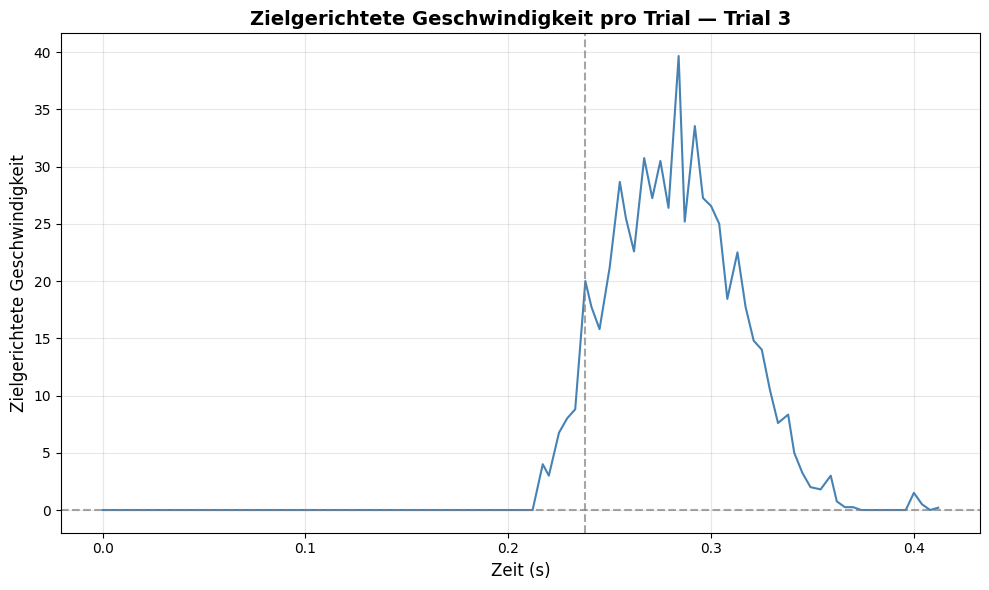

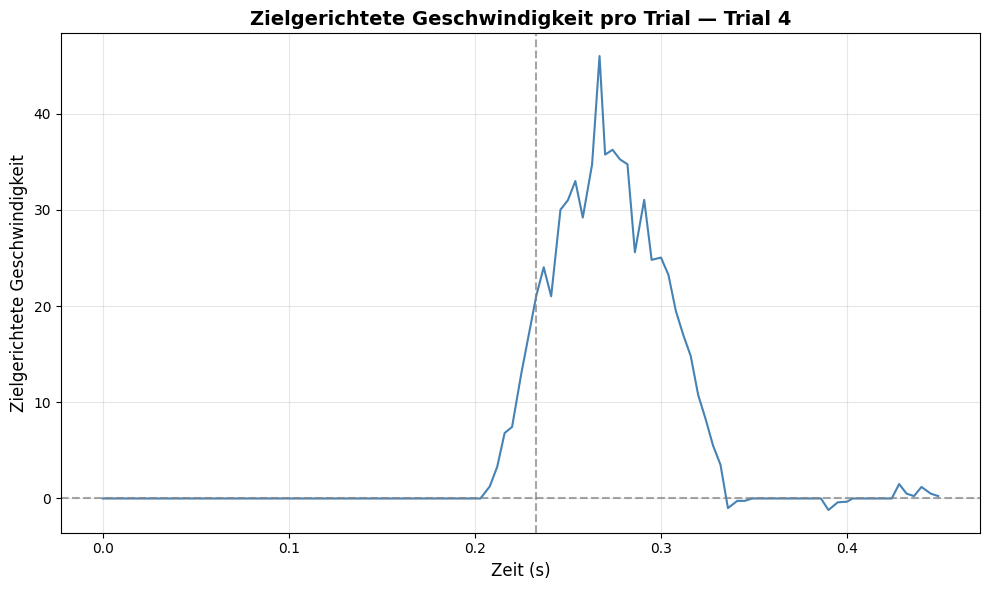

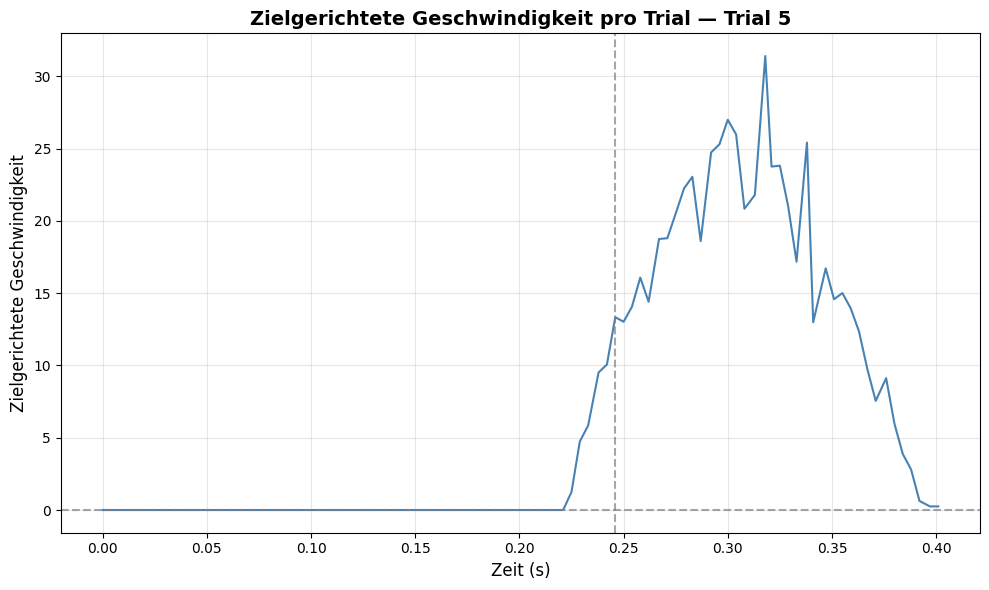

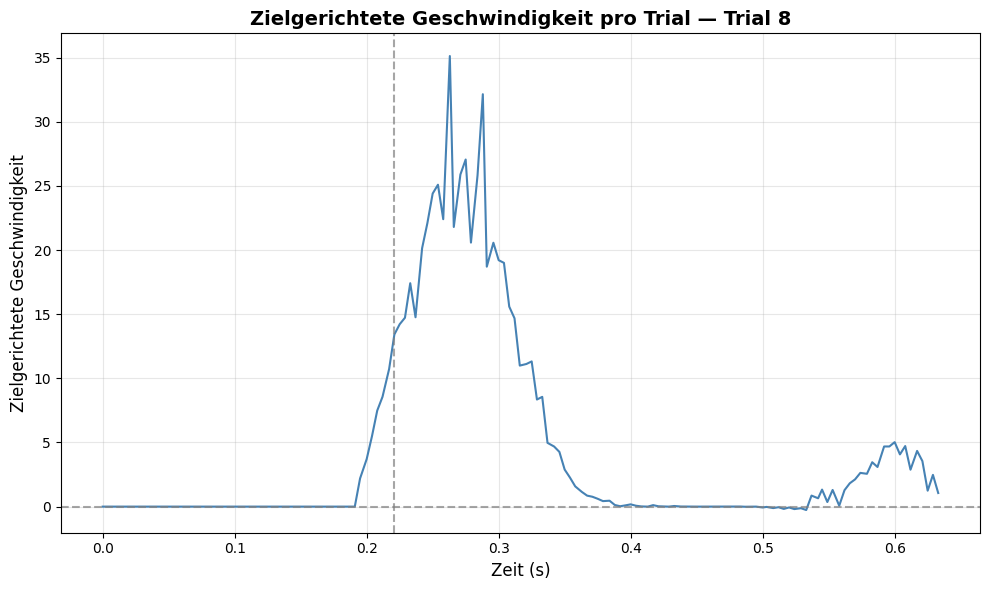

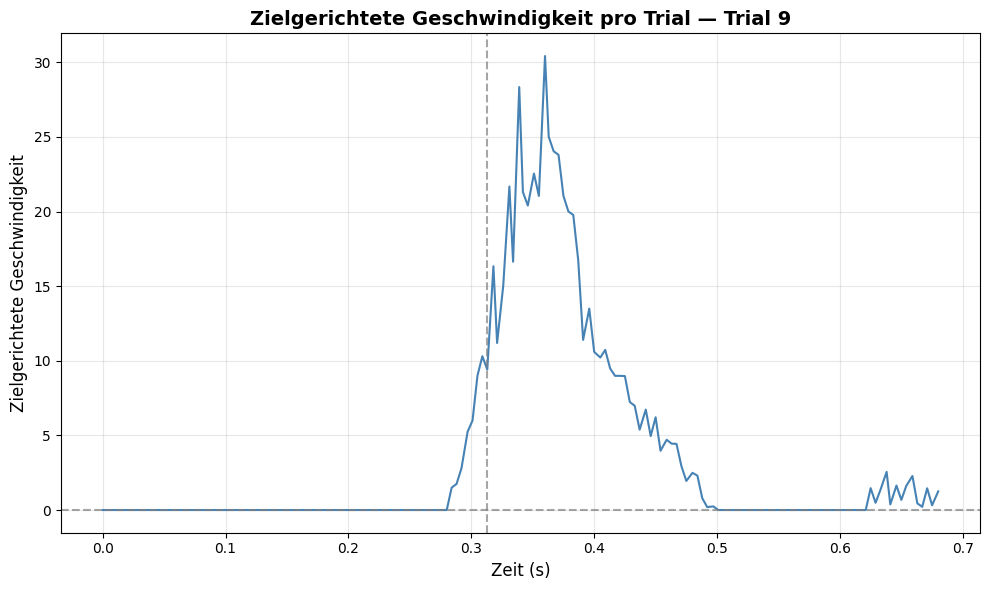

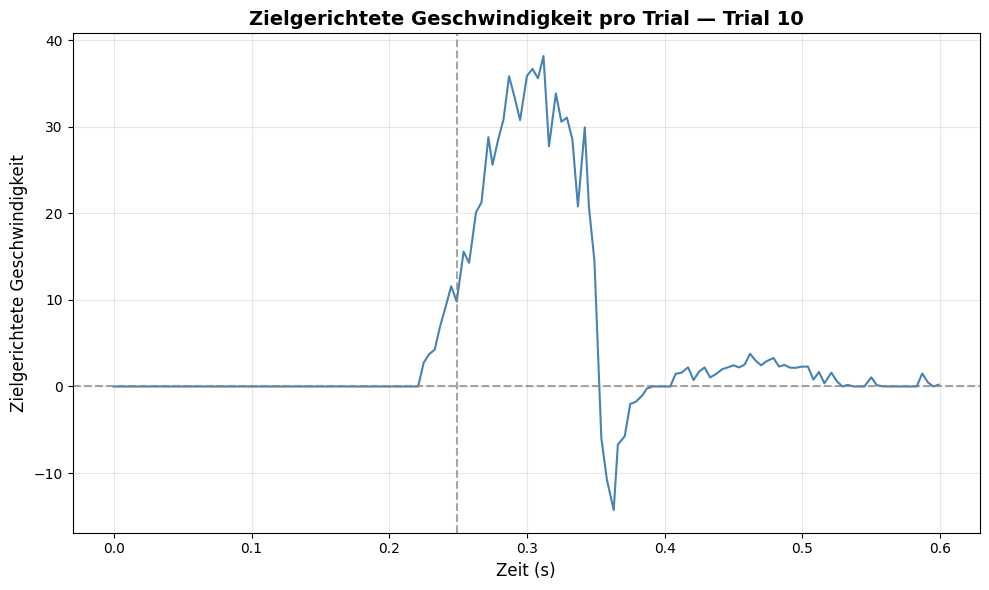

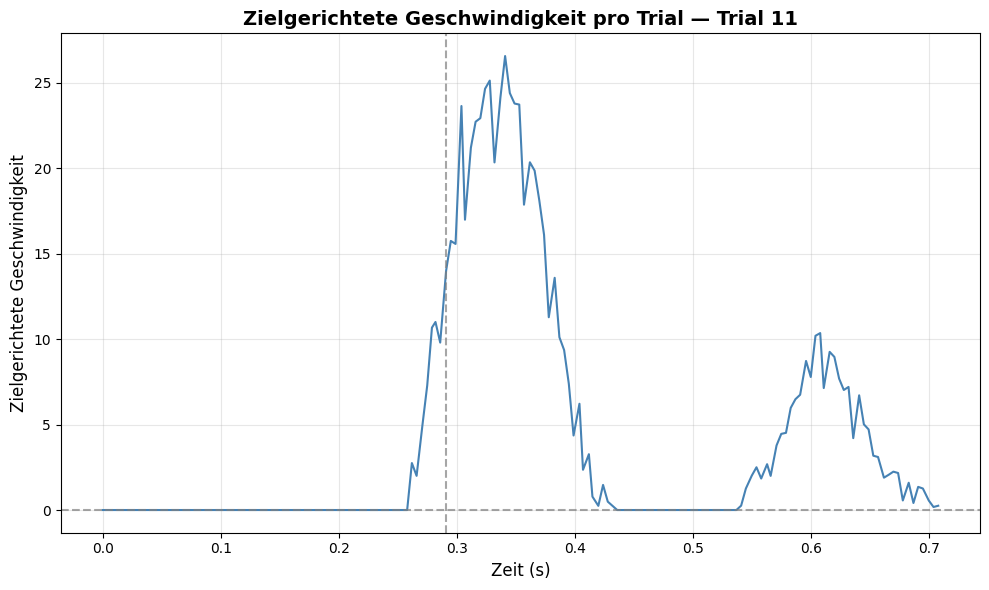

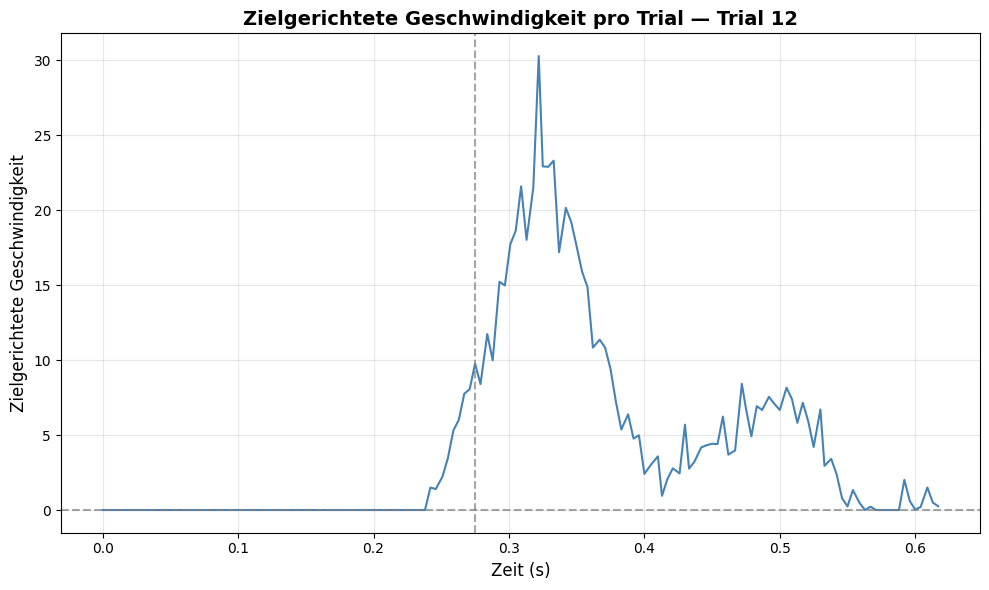

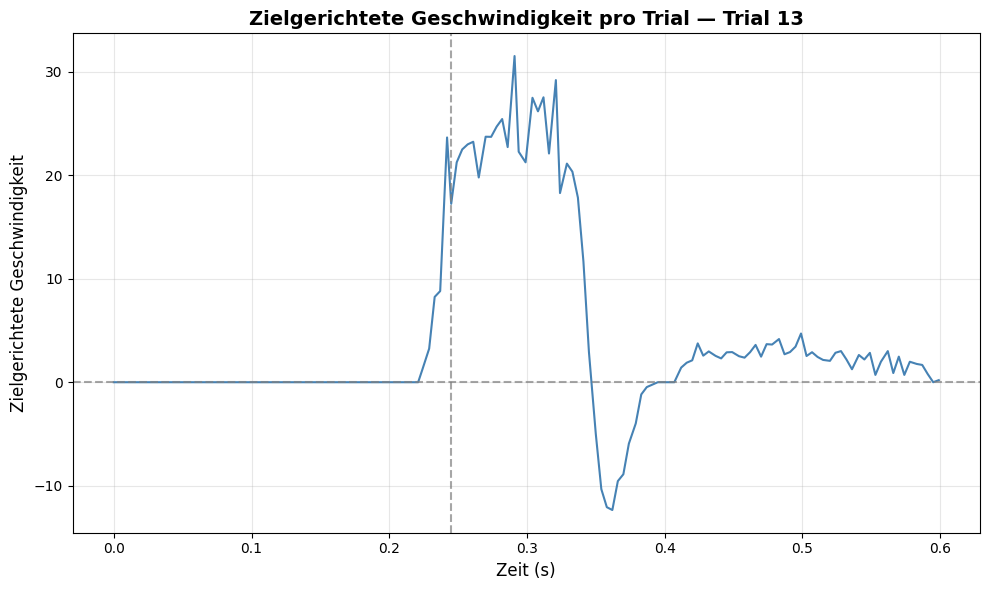

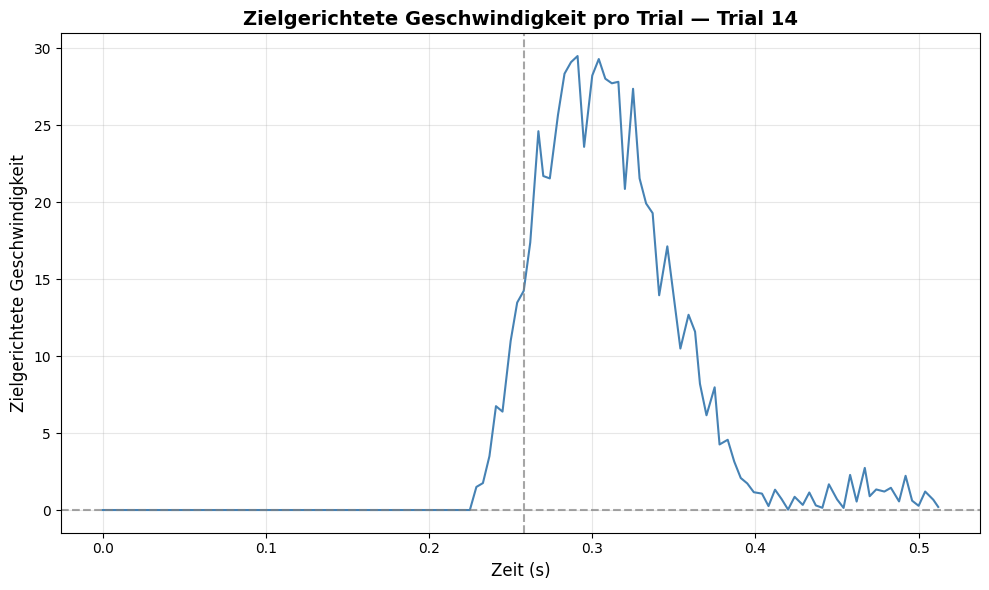

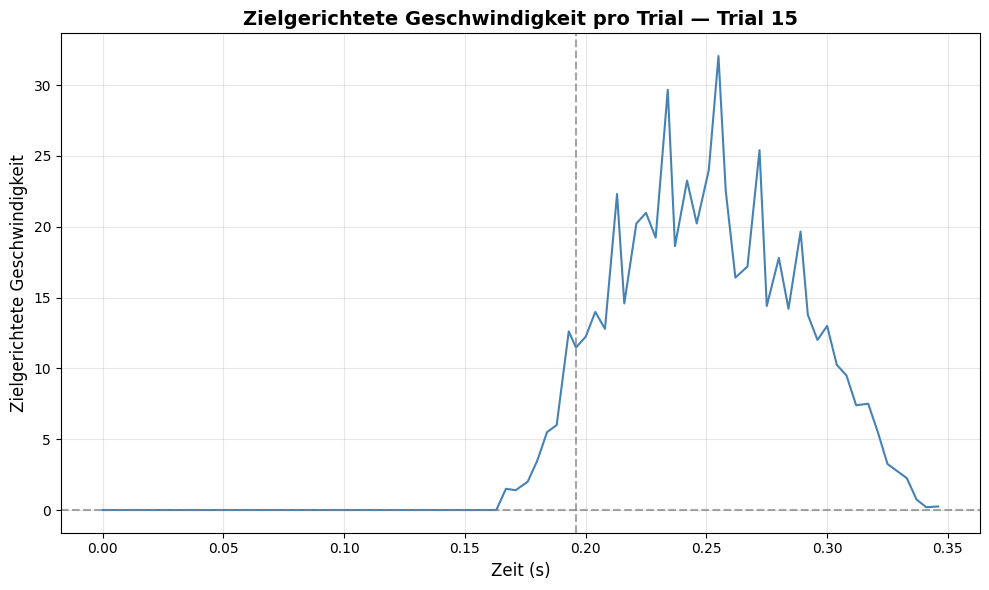

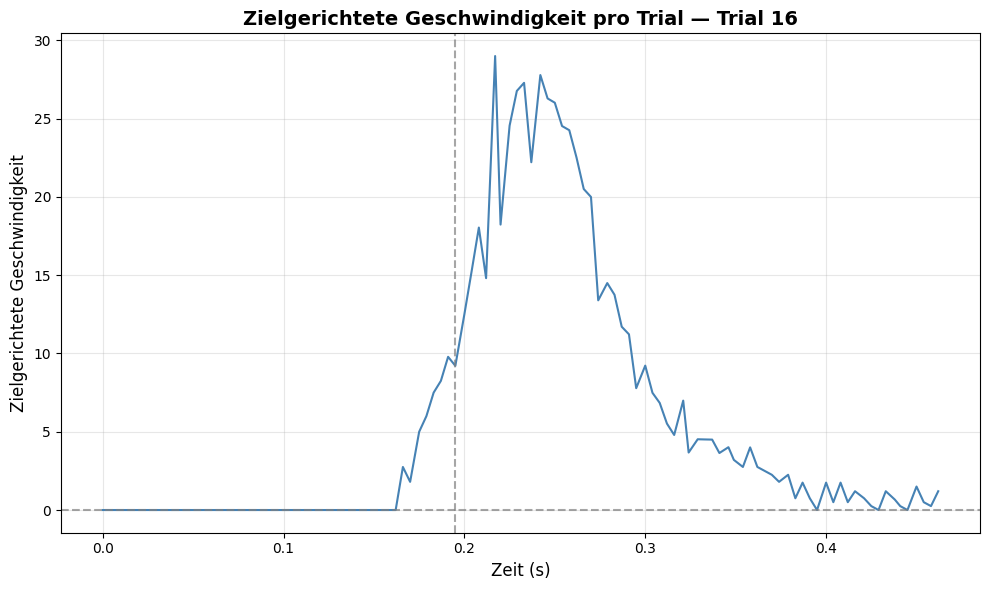

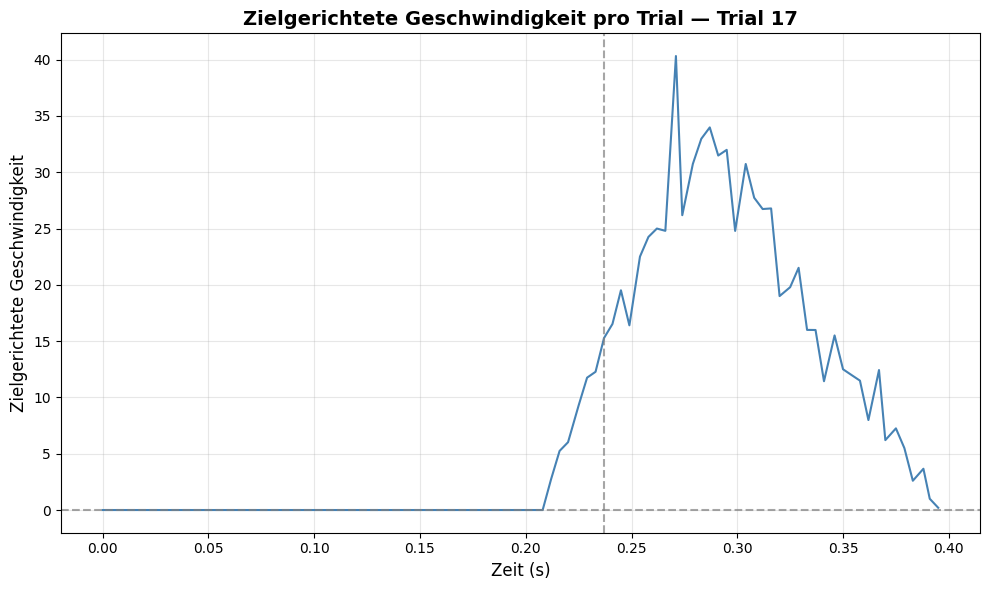

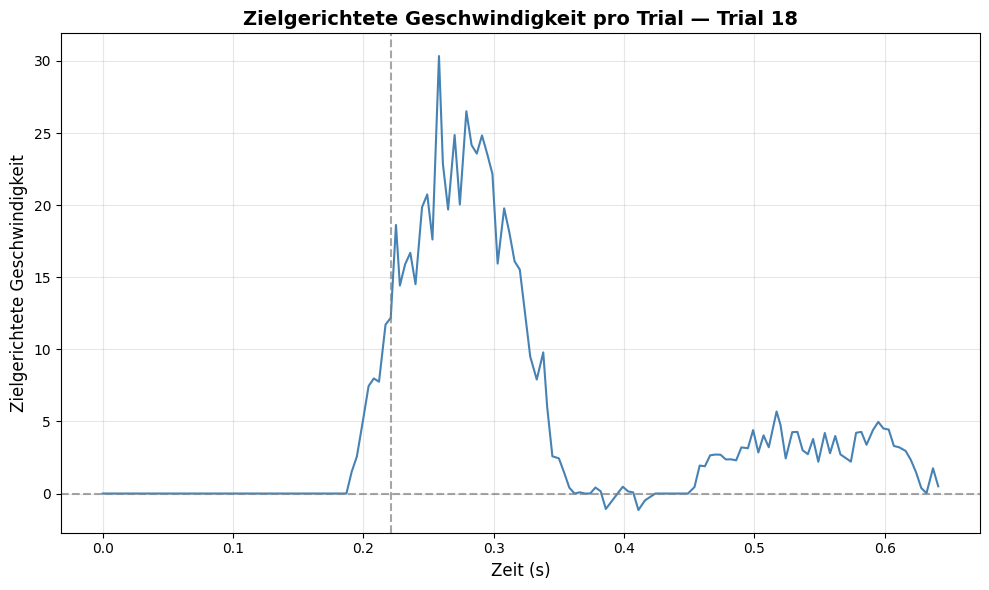

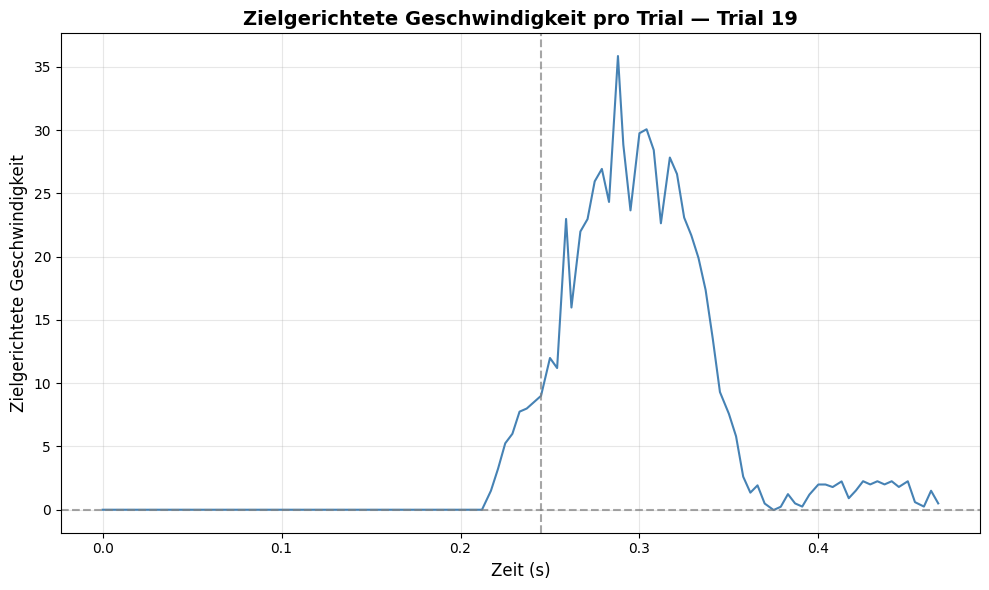

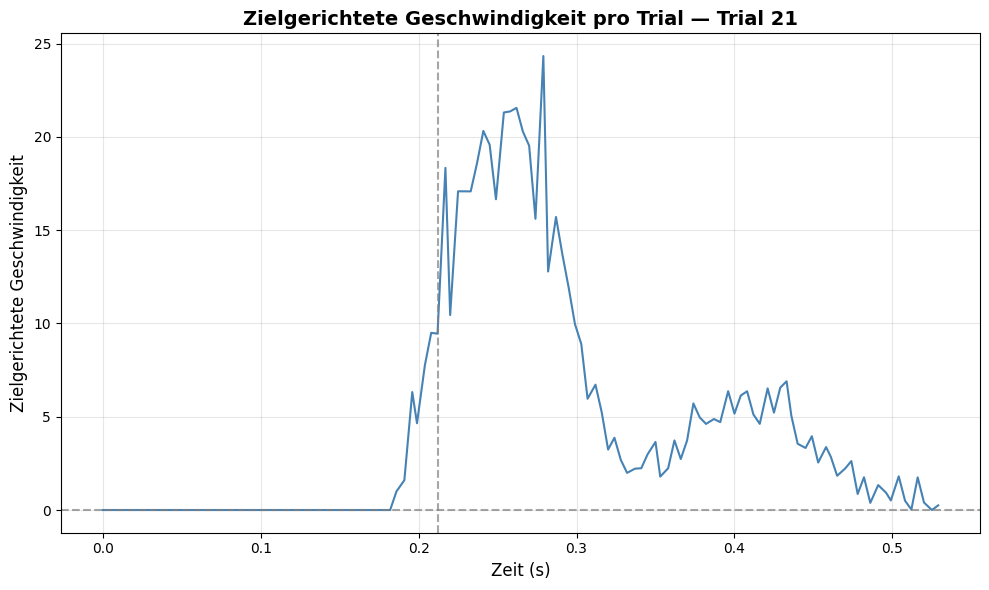

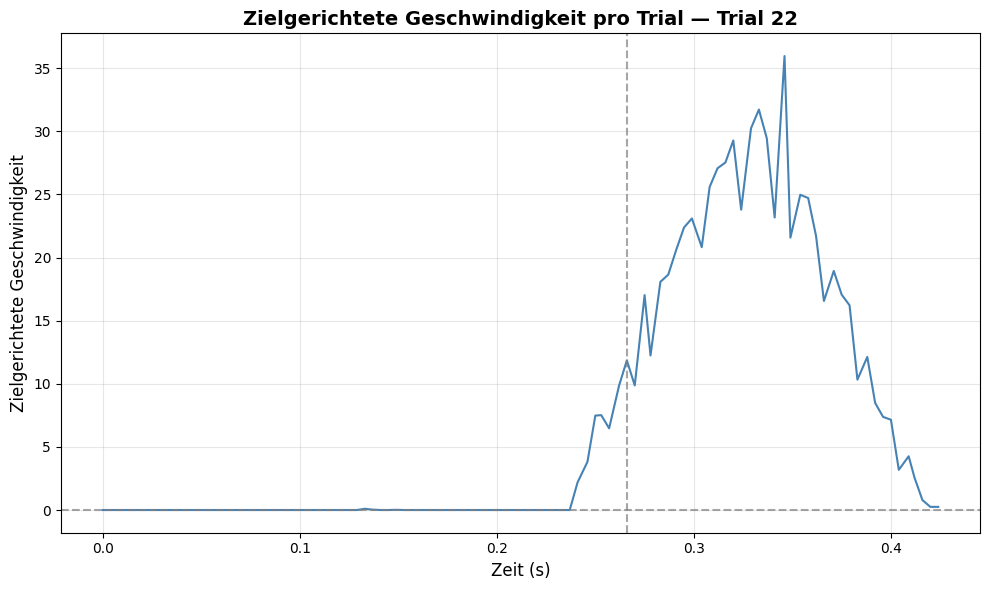

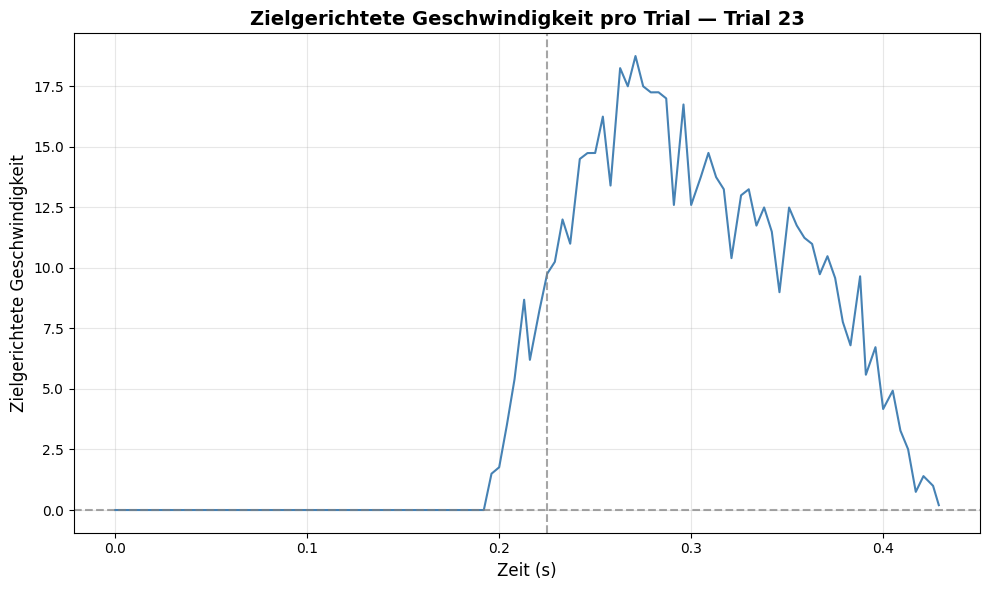

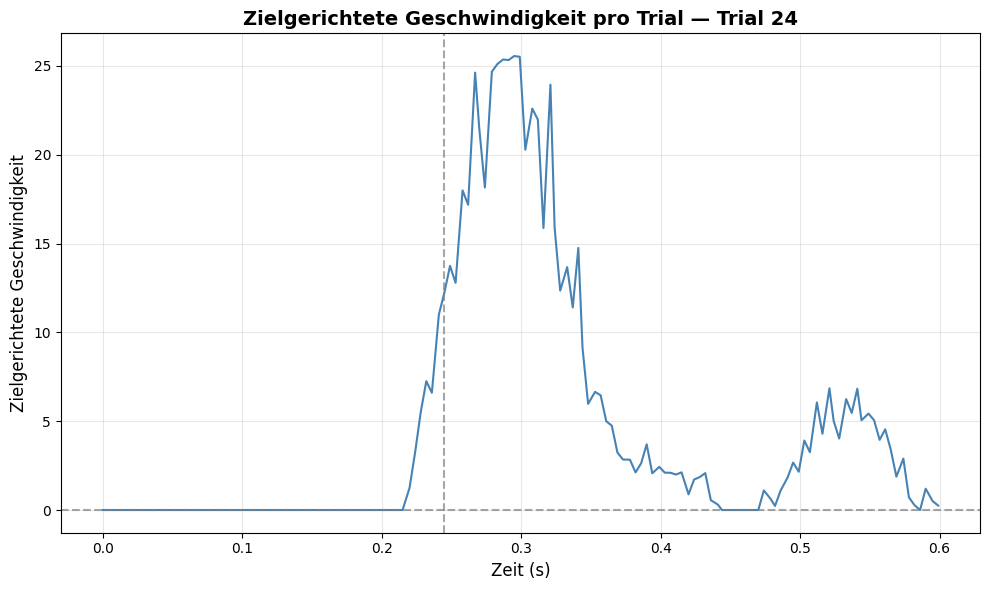

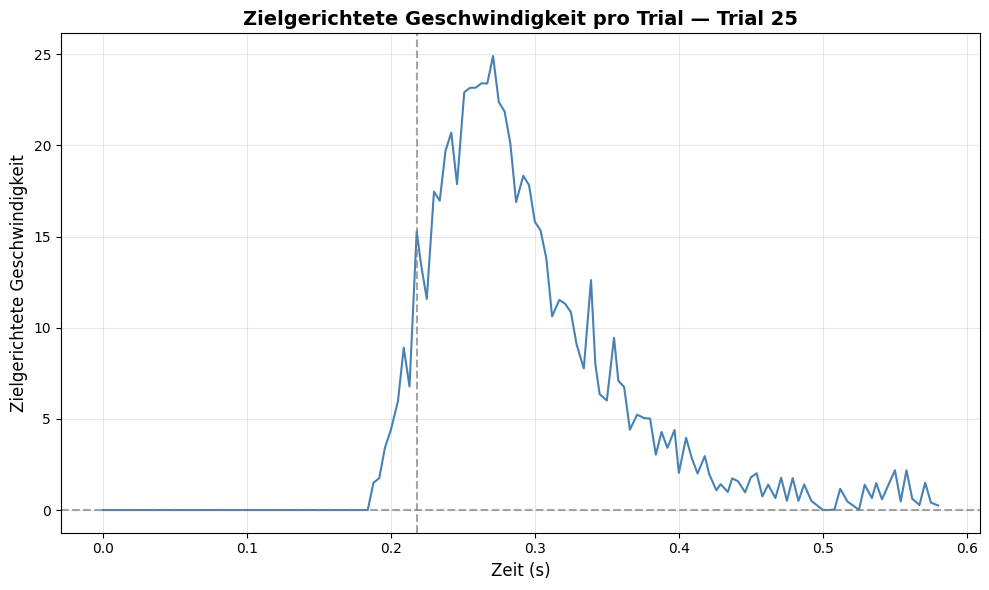

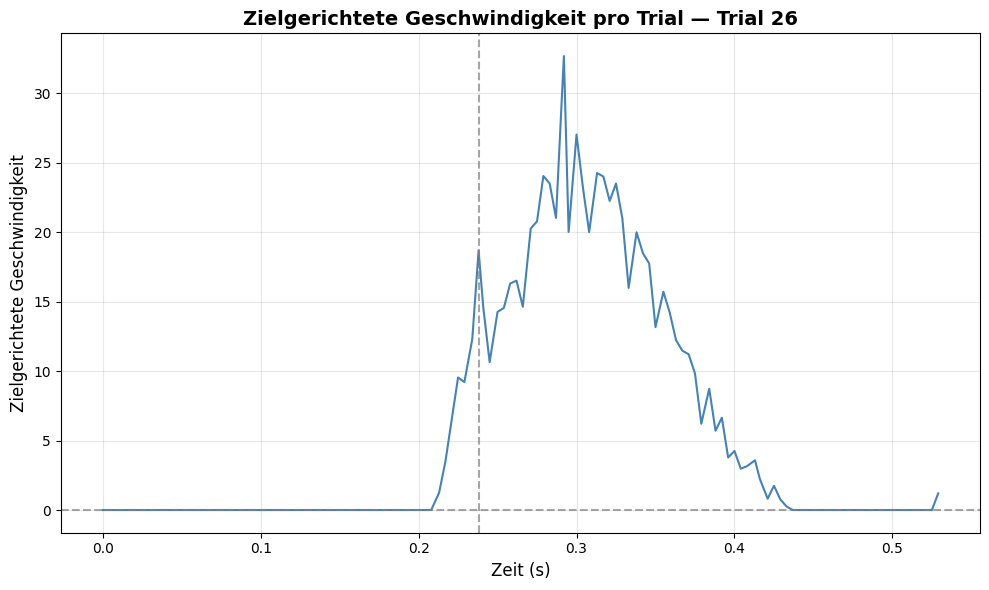

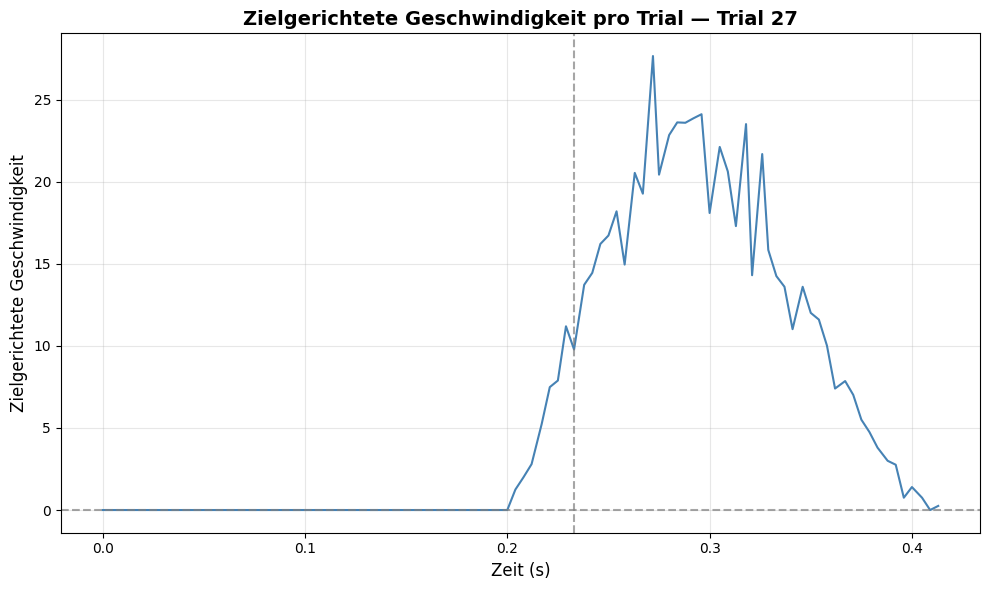

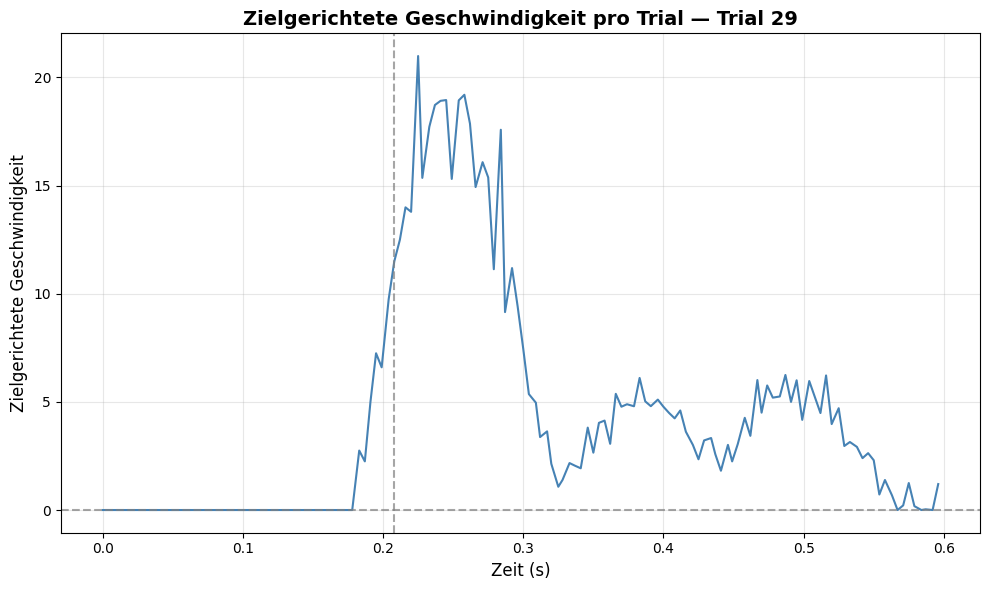

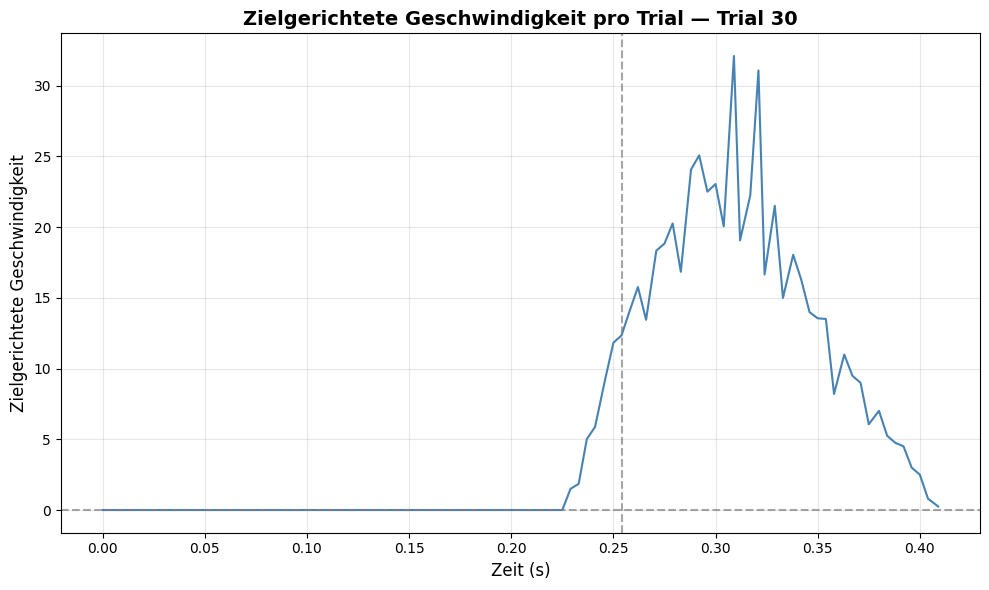

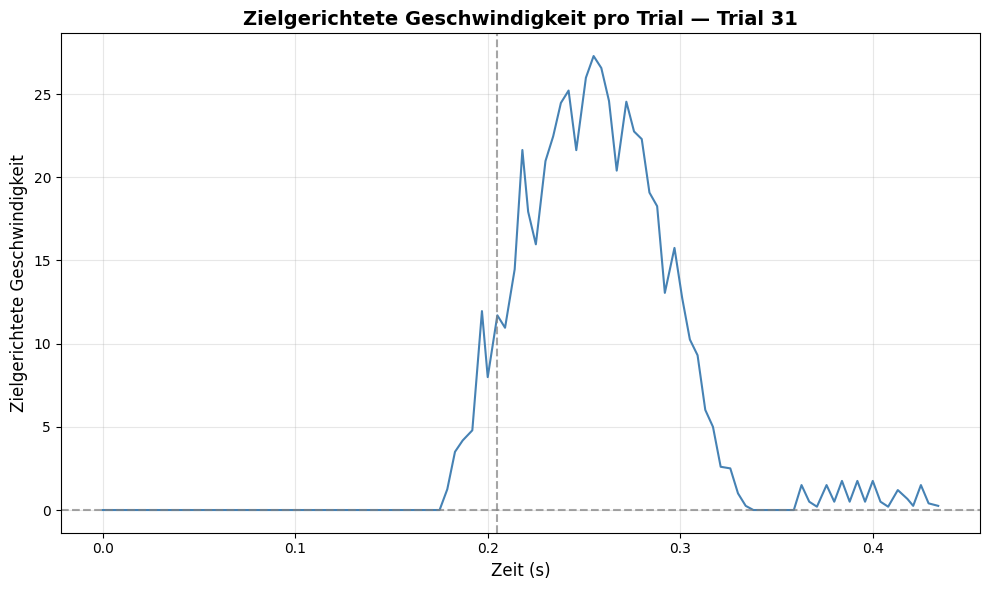

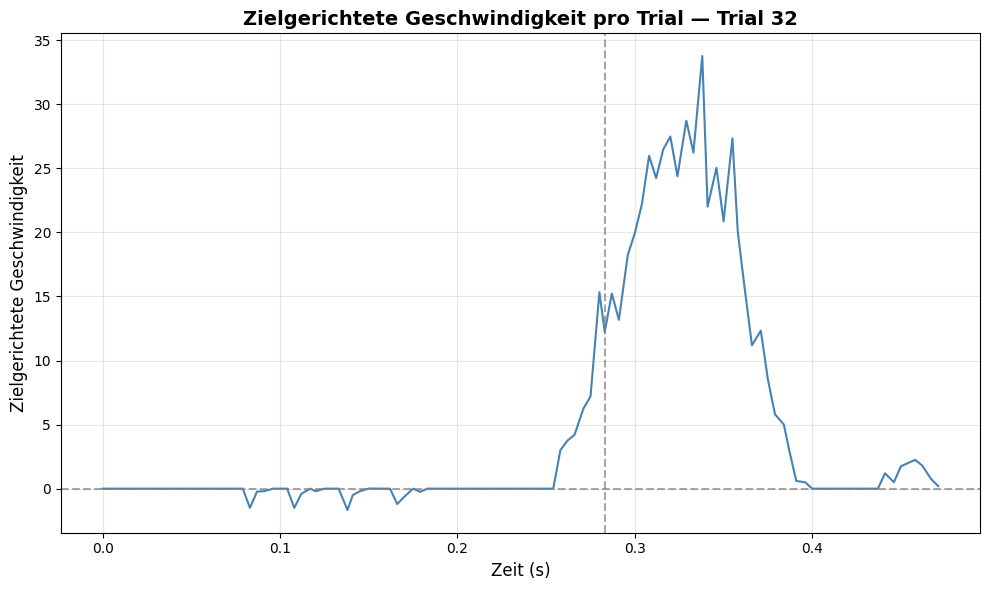

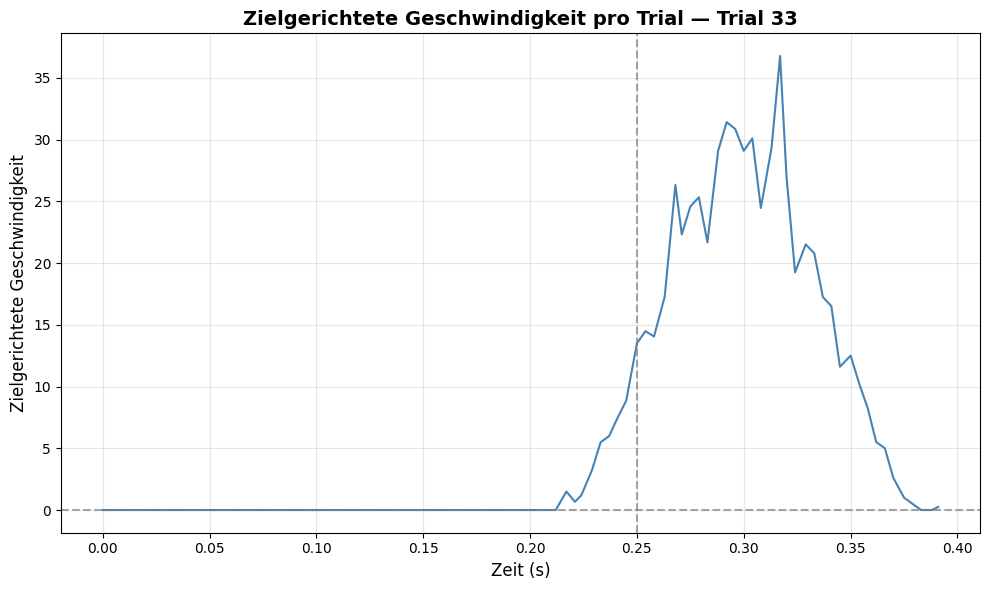

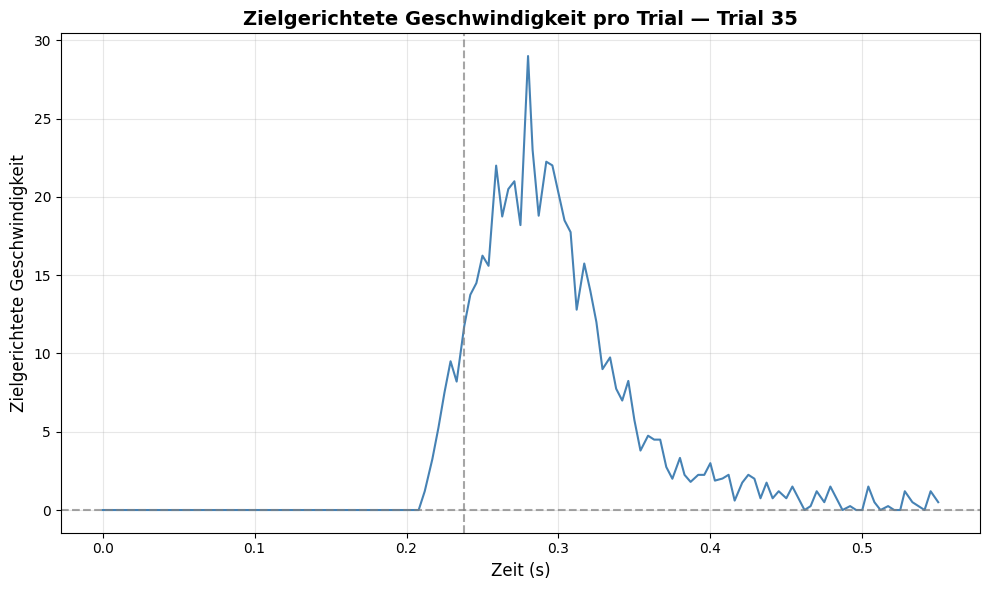

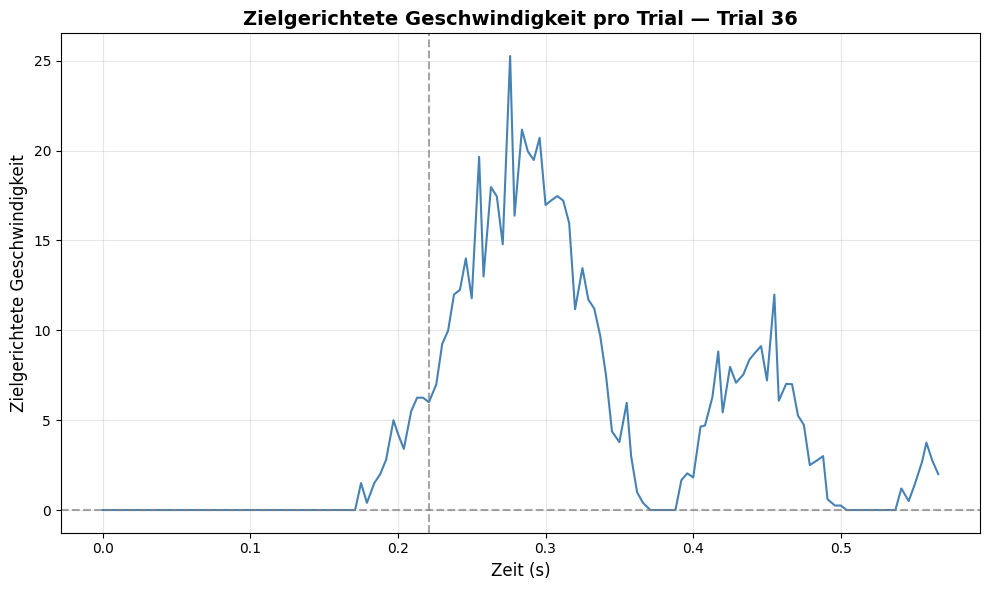

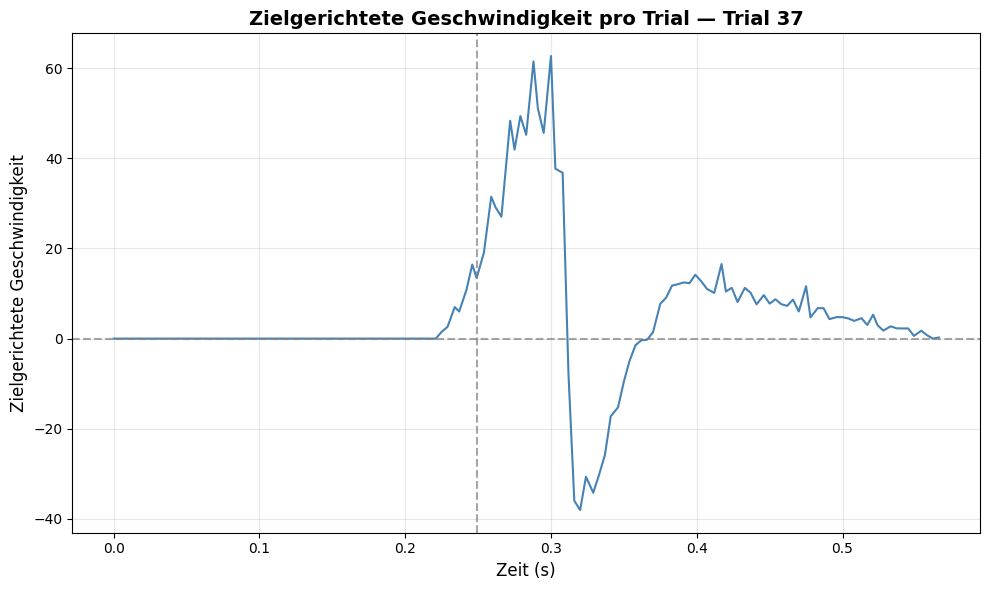

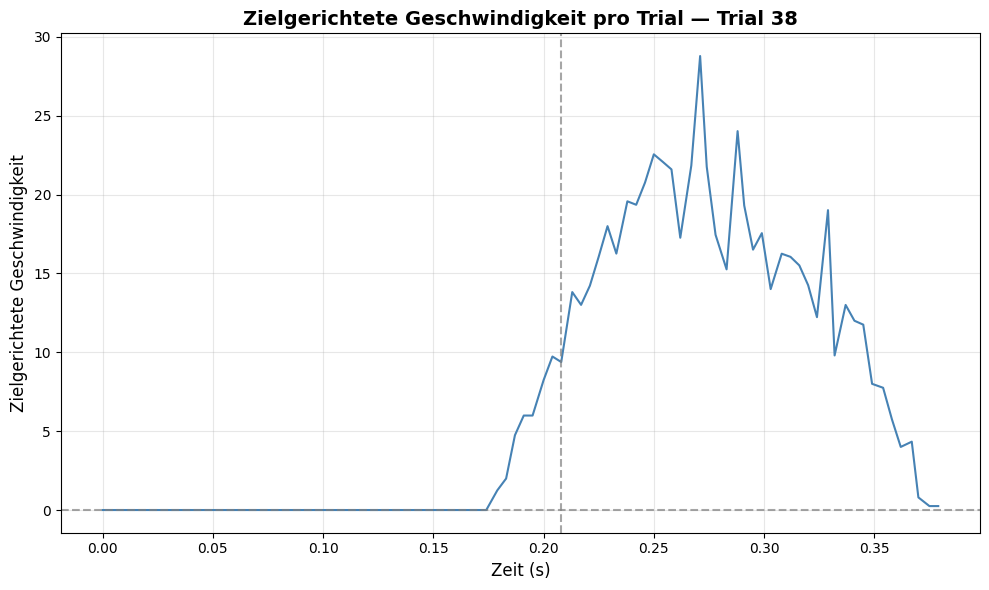

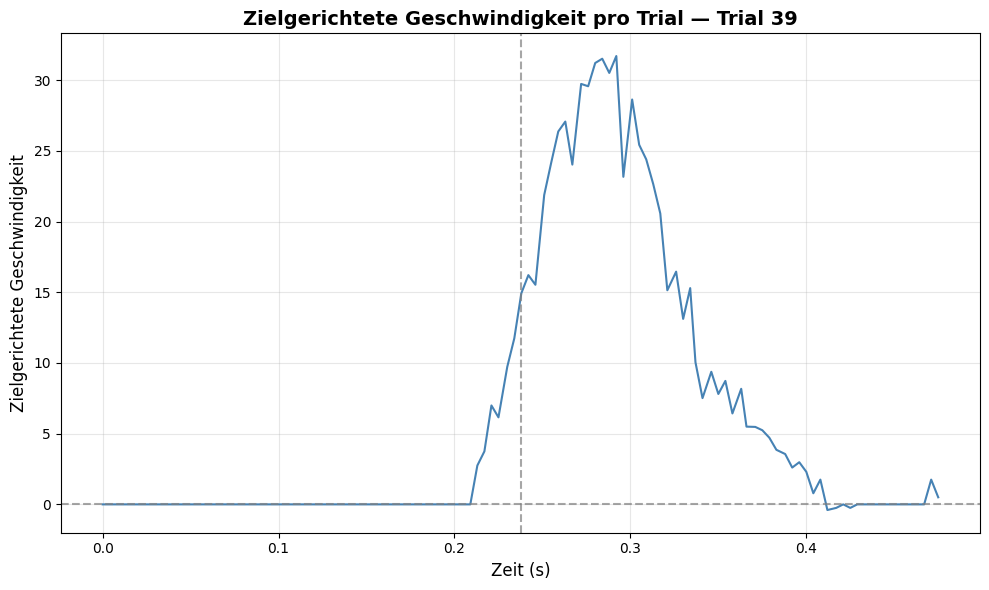

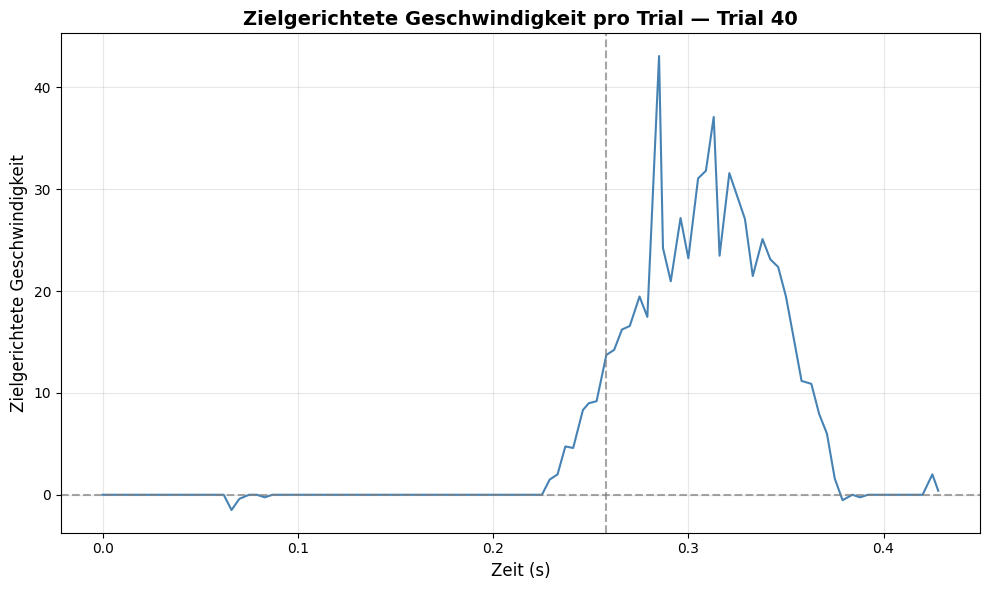

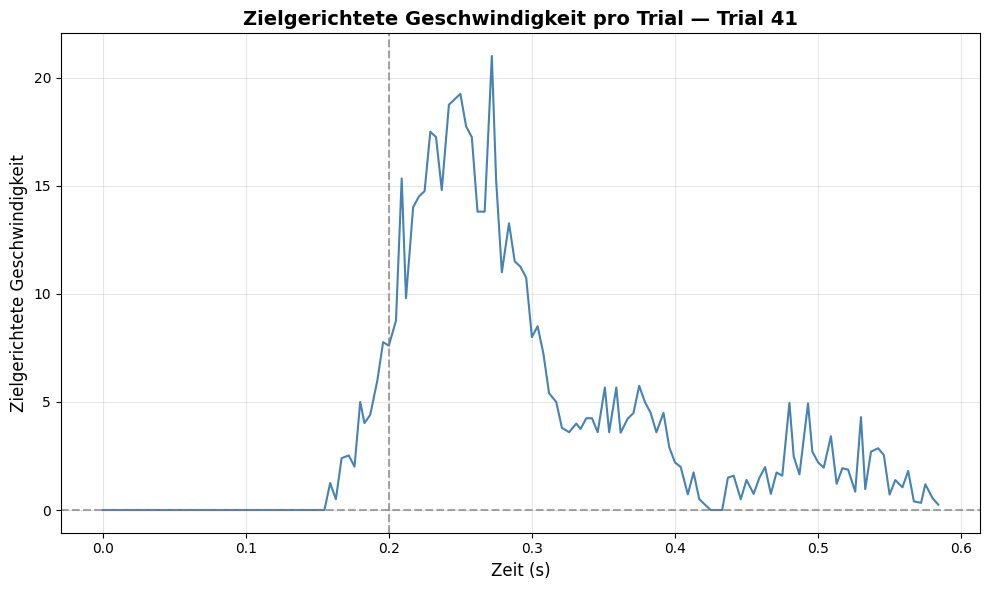

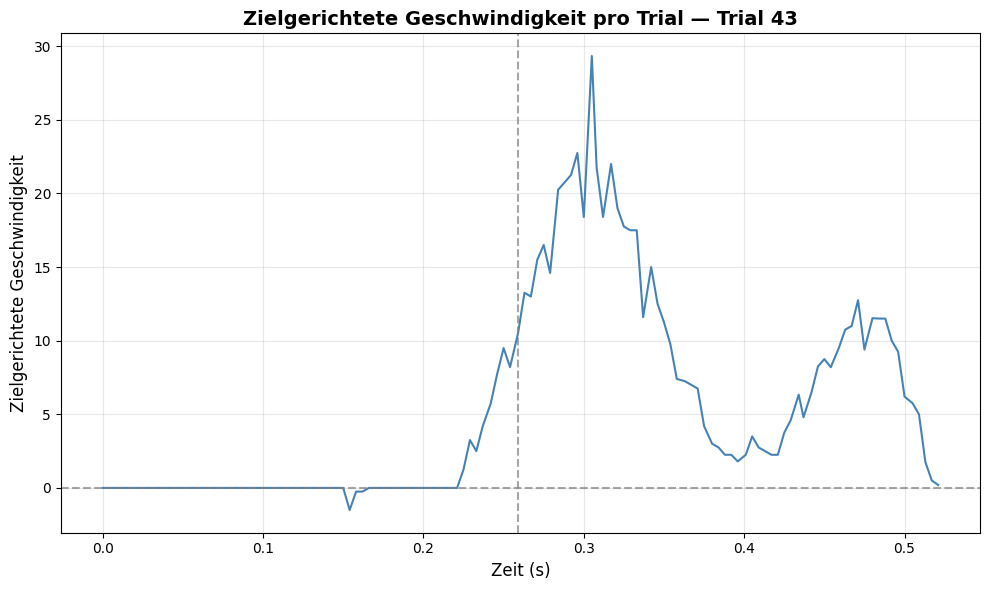

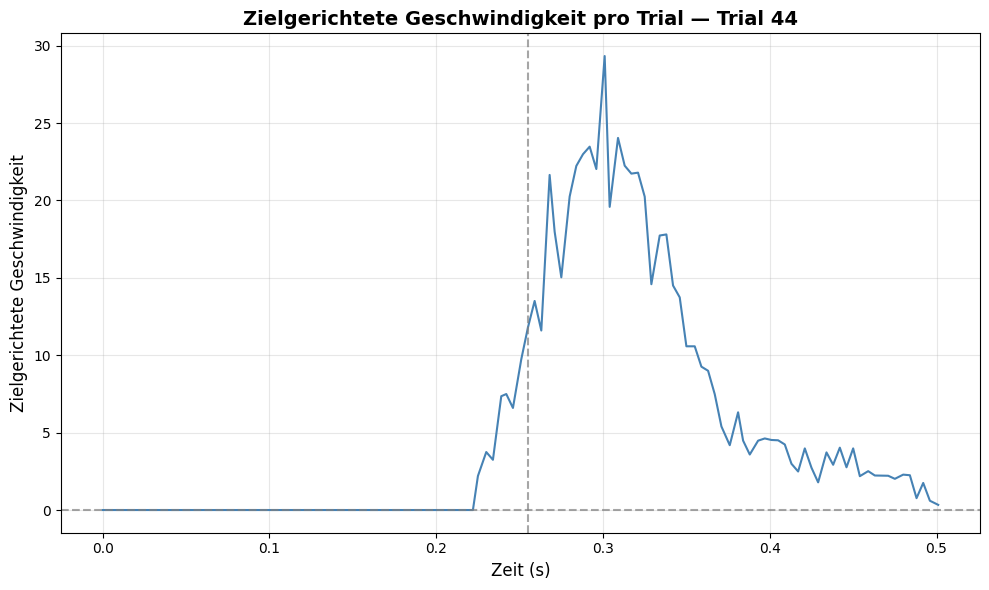

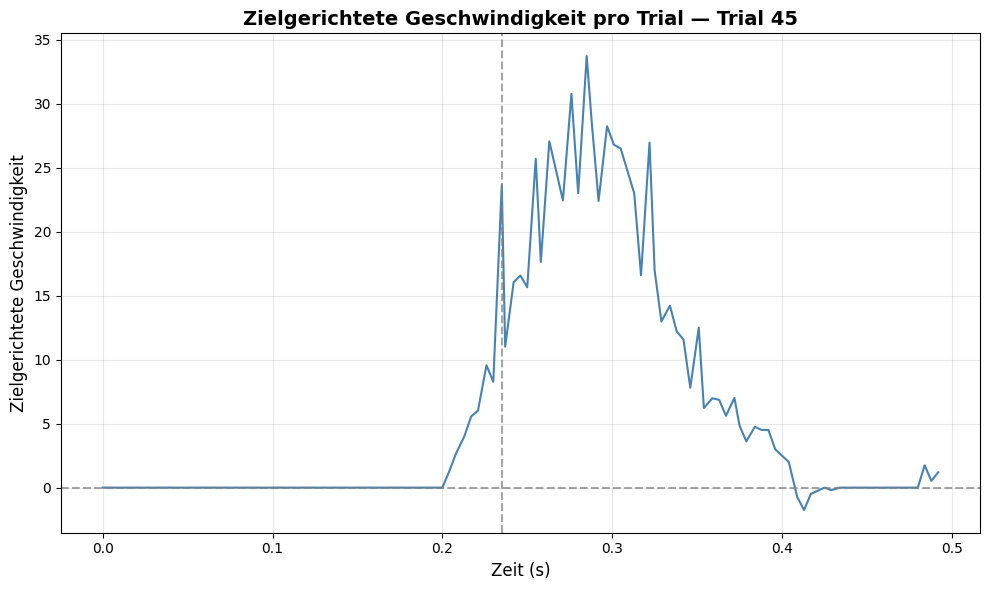

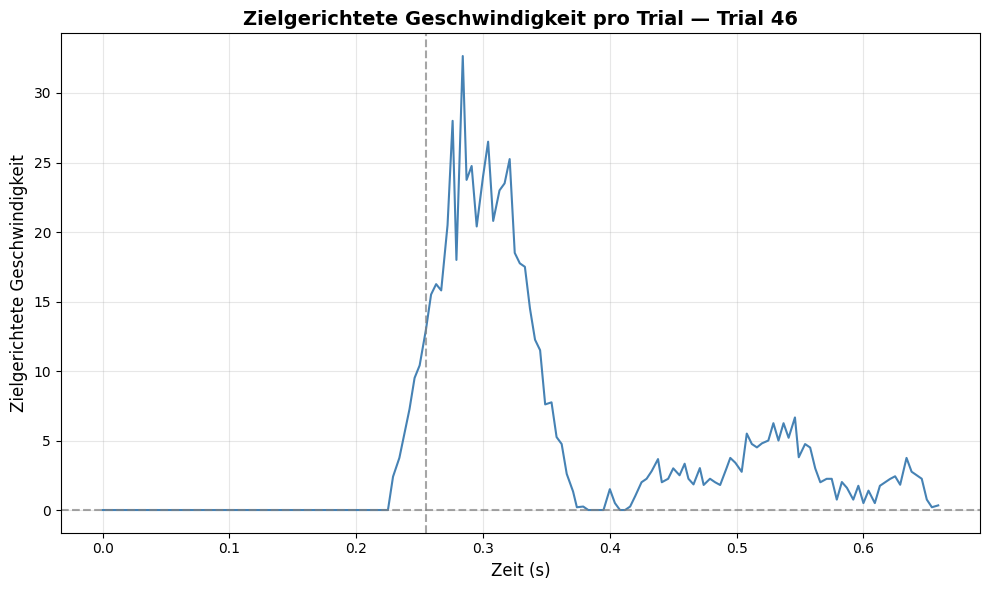

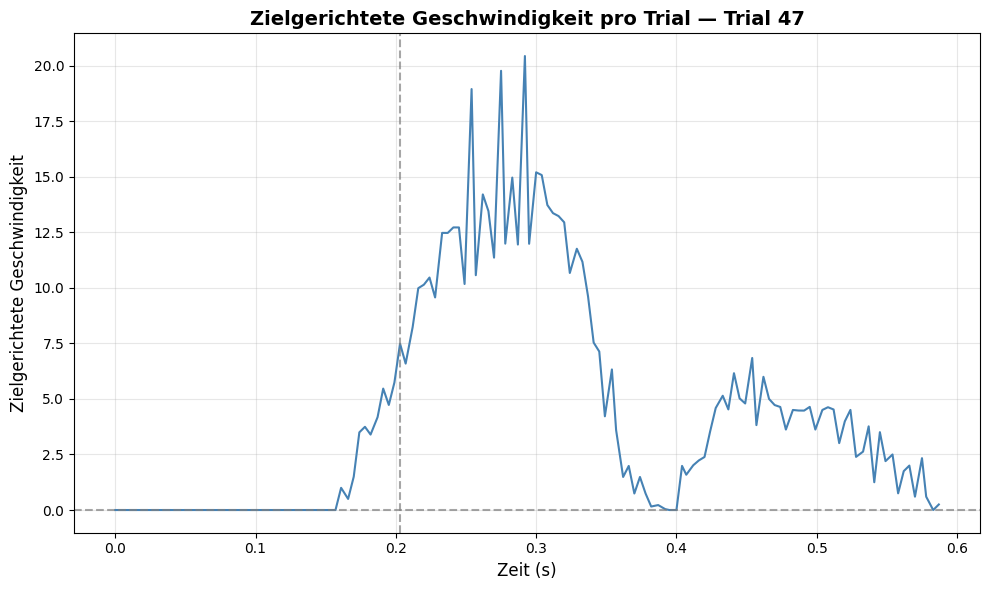

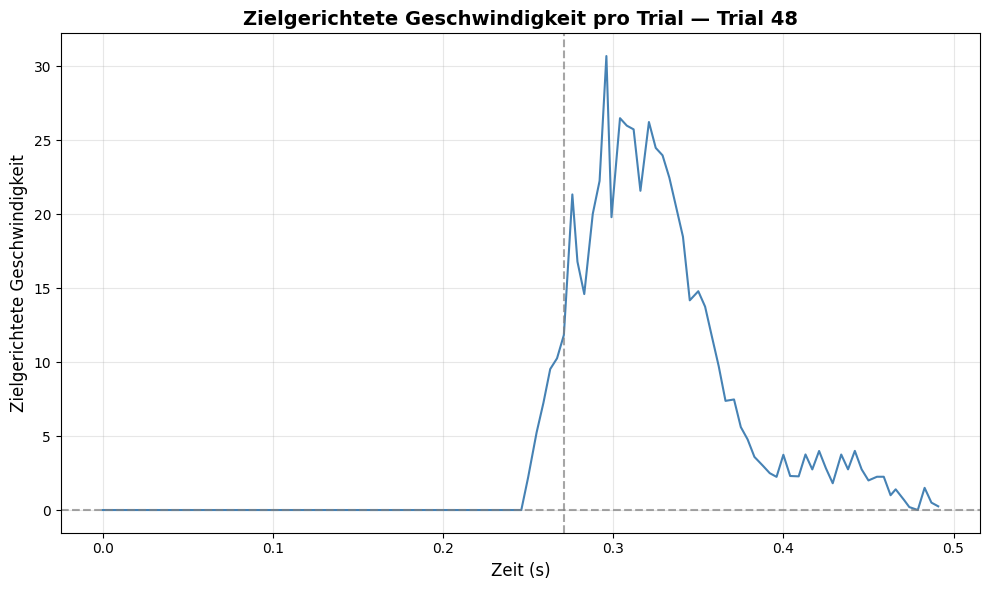

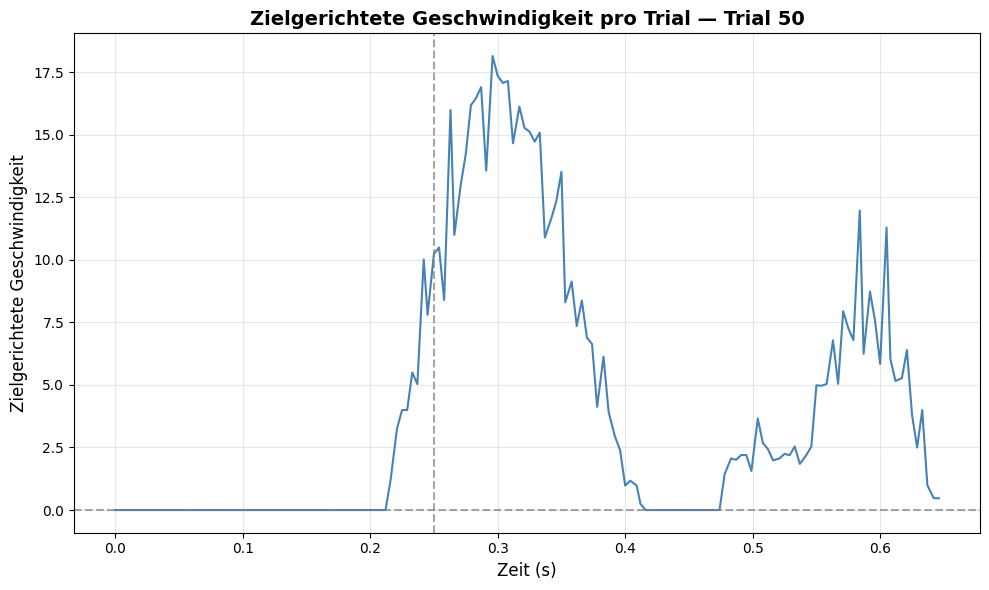

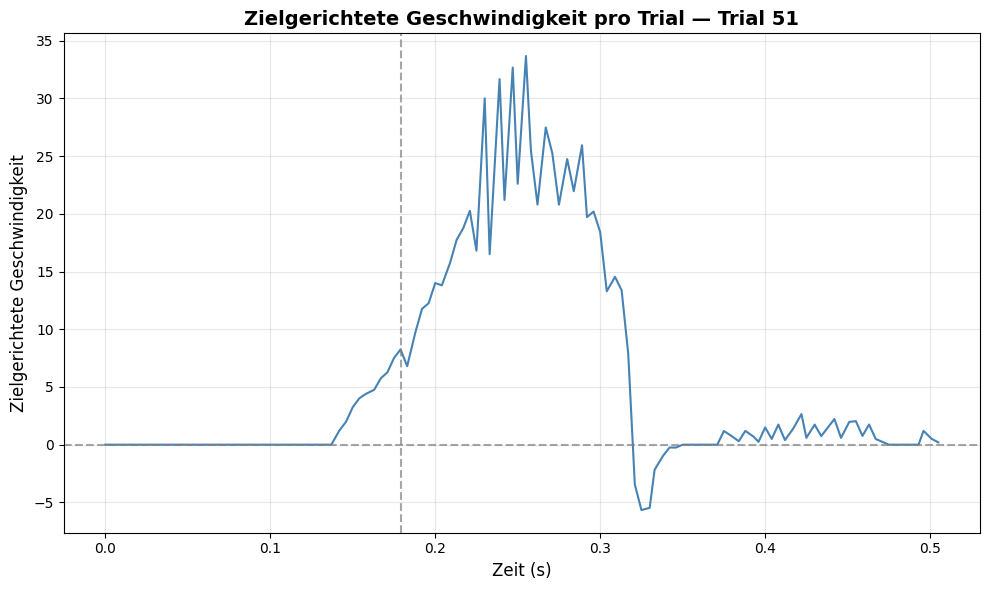

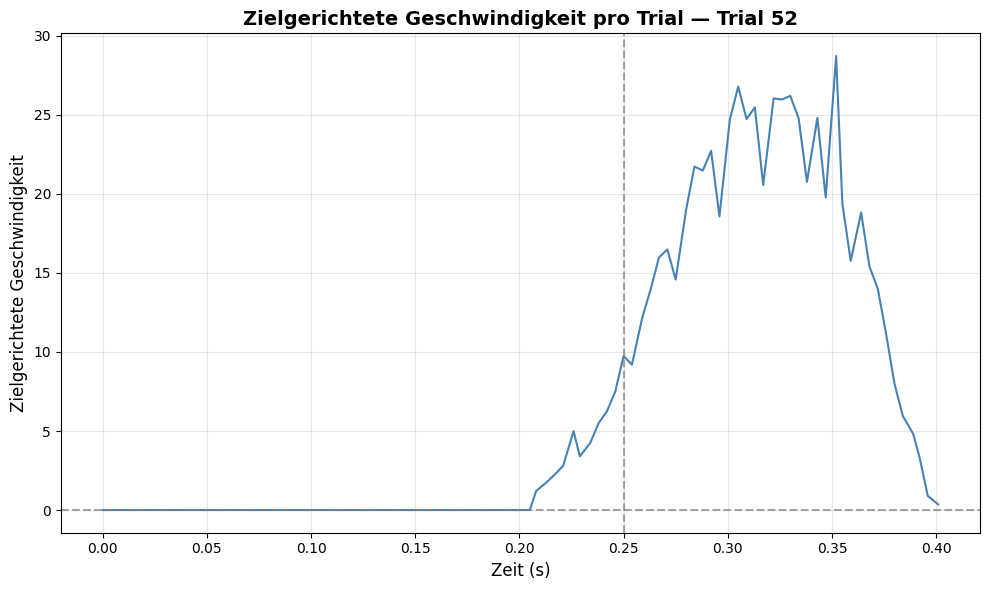

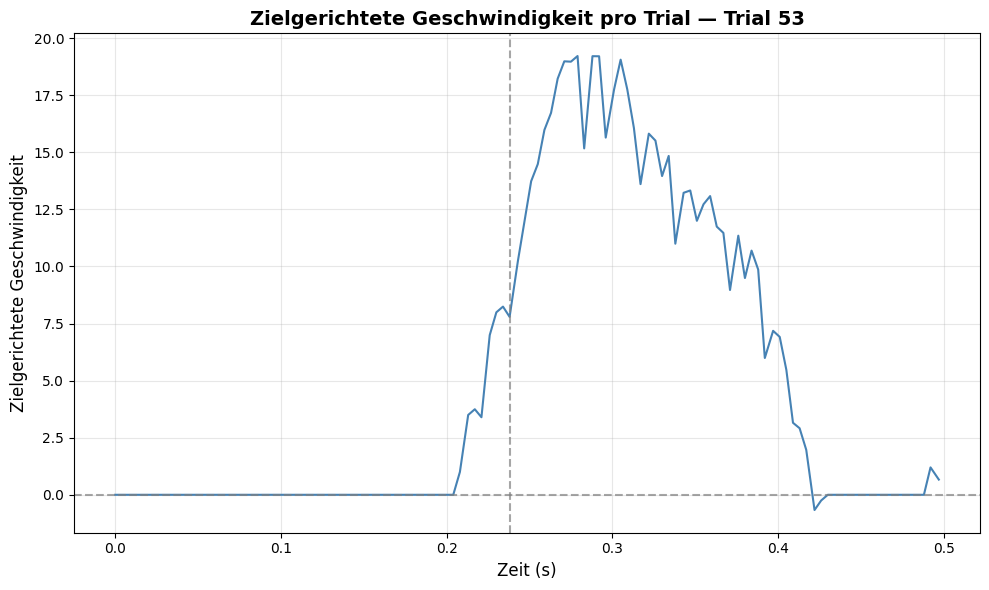

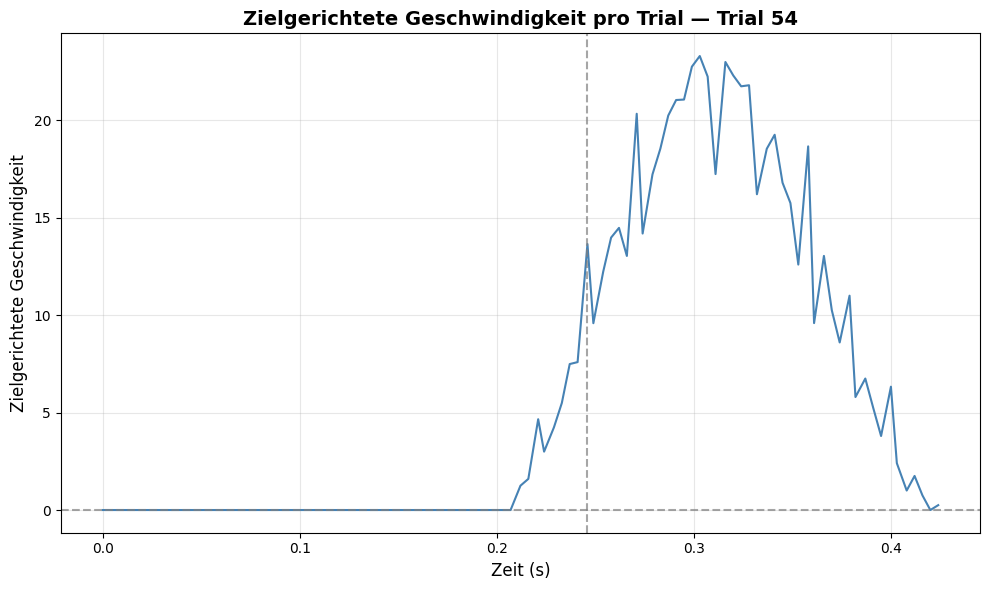

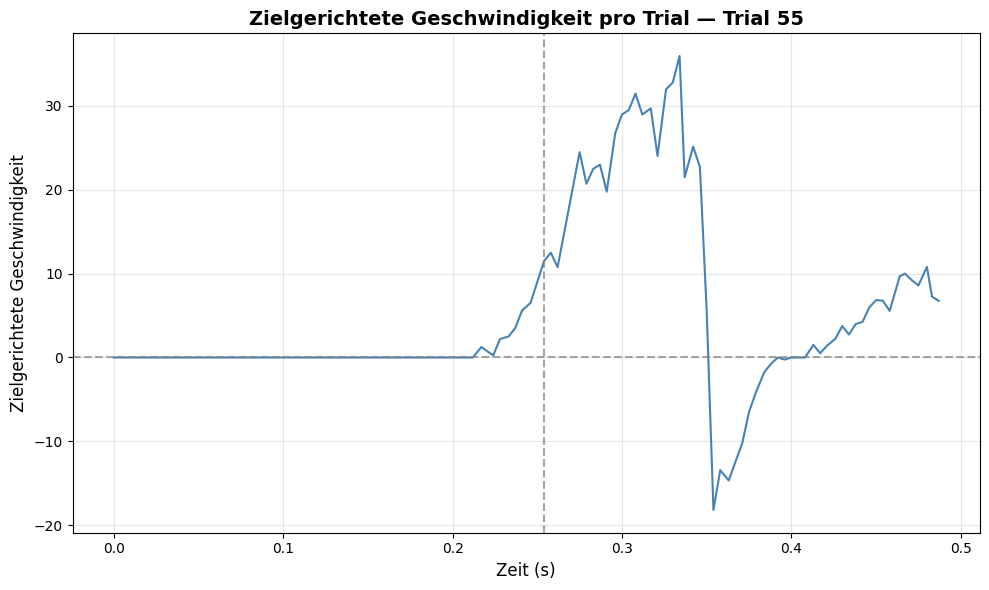

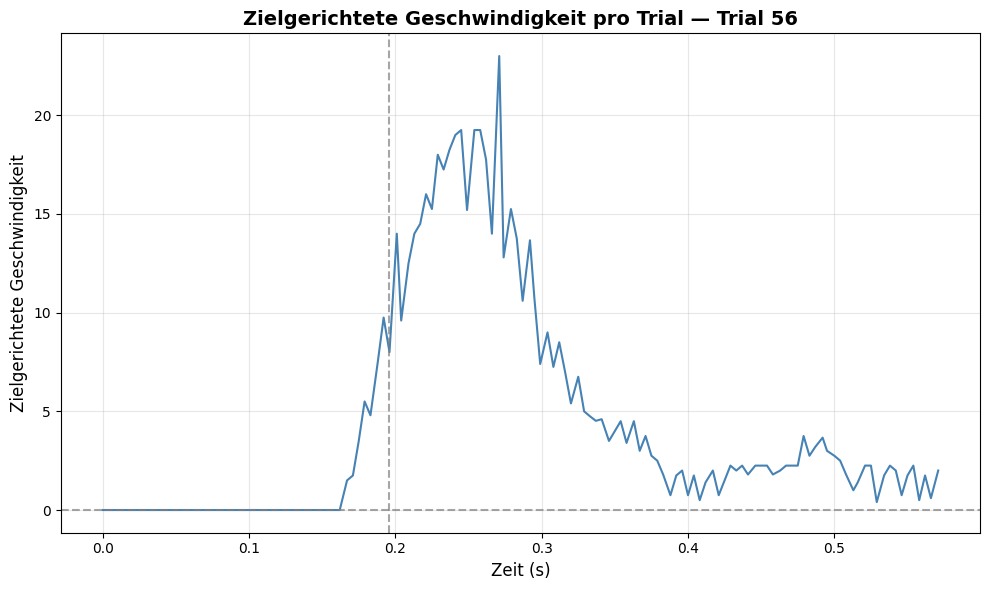

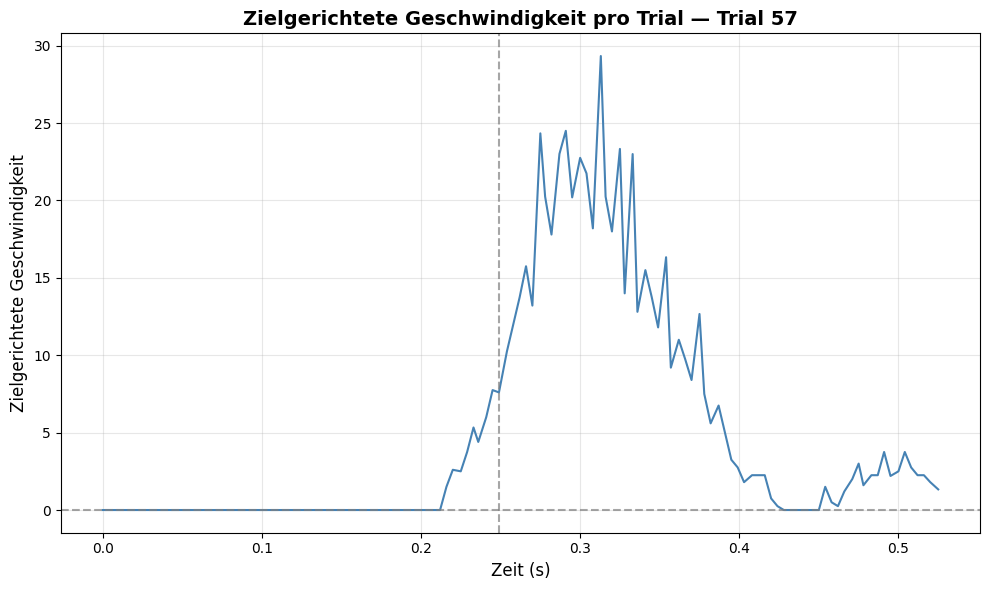

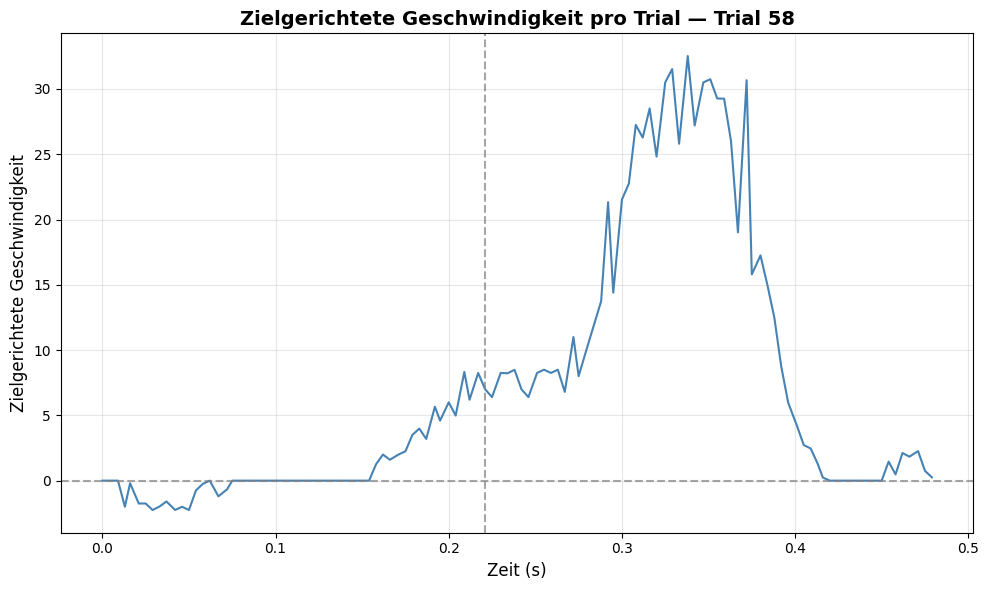

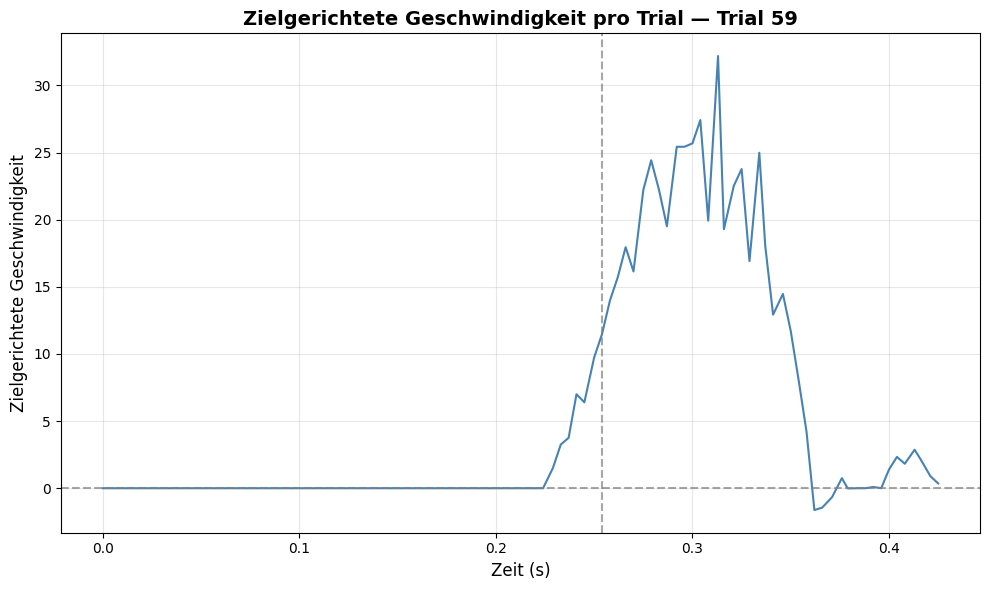

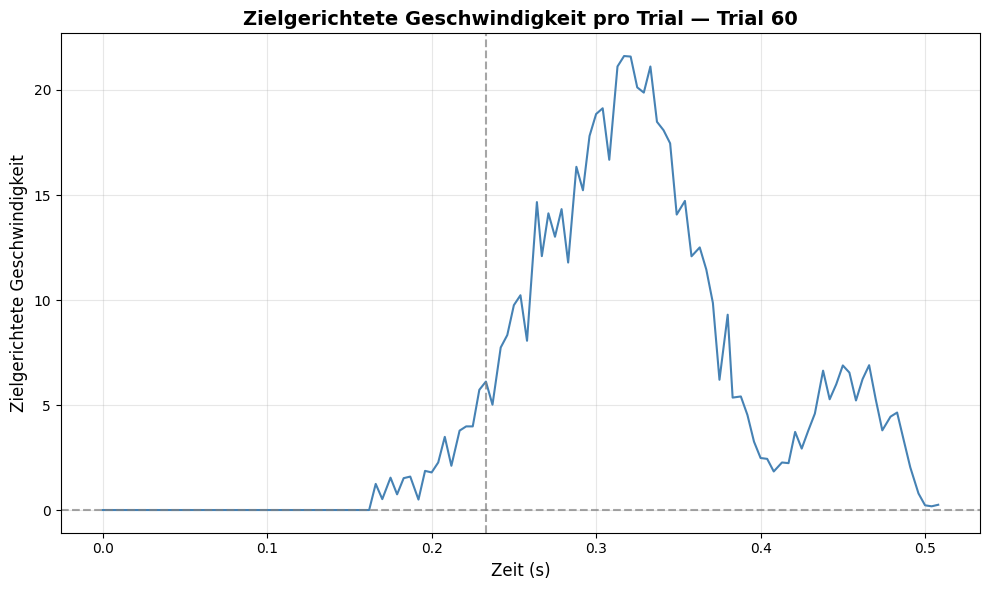

In [24]:
df_filtered = df[(df['id'] == 1062) & (df['round'] == 1)]

for _, trial_row in df_filtered.iterrows():
    trial_num = trial_row['trial']
    rel_time = trial_row['rel_time']
    velocity = trial_row['velocity_towards_target']
    rt_05pct = trial_row['rt_05pct_target']
    
    # Erstelle Plot für dieses Trial
    plt.figure(figsize=(10, 6))
    plt.plot(rel_time[:-1], velocity, color='steelblue', linewidth=1.5)
    plt.axhline(y=0, linestyle='--', color='grey', alpha=0.7)
    plt.axvline(x=rt_05pct, linestyle='--', color='grey', alpha=0.7)
    
    plt.title(f"Zielgerichtete Geschwindigkeit pro Trial — Trial {trial_num}", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Zeit (s)", fontsize=12)
    plt.ylabel("Zielgerichtete Geschwindigkeit", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()